# Context-Augmented Flaky Test Identification using Large Language Models

The evaluation is conducted on 12 paired experiments involving two frontier LLMs, three prompting strategies, and two context configurations over the same benchmark dataset.


# 1. Research Questions & Hypotheses

>RQ1 : How accurately can modern LLMs identify flaky tests using only test code?

Hypothesis H1: Modern LLMs can identify flaky tests with reasonable predictive performance using only the test implementation, providing a baseline against which context augmentation can be evaluated.

>RQ2 : Does context augmentation improve flaky test identification?

Hypothesis H2: Providing contextual software artifacts enables LLMs to identify flaky tests more accurately than using test code alone.

>RQ3 : Which prompting strategy provides the most reliable classification performance?

Hypothesis H3: Structured reasoning prompts outperform direct Zero-Shot prompting.

>RQ4 : Which contextual software artefacts contribute most to correct classifications?

Hypothesis H4: Production code and runtime failure information contribute more than helper methods alone.

>RQ5 : What characteristics make a flaky test difficult for LLM-based identification?

Hypothesis H5: Flaky tests involving complex software behaviors or ambiguous failure causes remain more difficult for LLM-based identification than flaky tests with explicit runtime failure evidence.


## 1.1 Executive Summary : Key Findings at a Glance

This notebook evaluates 12 experimental configurations (2 LLMs × 3 prompting strategies × 2 context settings) on a benchmark of 2,210 unique test cases, perfectly balanced between Flaky and Non-Flaky (1,105 each). All figures below are cross-referenced to the section that derives them.

| # | Research Question | Headline Finding | Section |
|---|---|---|---|
| RQ1 | Can LLMs identify flaky tests from test code alone? | **Partially.** High precision (82–88%) but very low recall (7–14%) : models rarely predict "Flaky" and miss most real flaky tests. | [S3](#3-baseline-performance-evaluation-rq1) |
| RQ2 | Does context augmentation help? | **Yes, substantially.** F1 improves from as low as ~18% to as high as ~75% depending on configuration; every model/prompt pair improves with statistical significance (McNemar's test, Holm-Bonferroni corrected, p < 0.05). | [S4](#4-context-augmentation-analysis-rq2) |
| RQ3 | Which prompting strategy is most reliable? | **Depends on context availability.** Few-Shot CoT wins without context, but becomes the *weakest* strategy once context is added — Zero-Shot / Zero-Shot CoT take over. | [S5](#5-prompt-strategy-evaluation-rq3) |
| RQ4 | Which contextual artefacts matter most? | **Failure Log and Production Code**, most often used together with Test Code (97% and 75% utilization in successful classifications) — Helper Methods are supplementary (39%). | [S6](#6-contextual-artefact-contribution-rq4) |
| RQ5 | What makes a flaky test hard to classify? | **Implicit-cause categories remain hard even with context.** True subtype-match accuracy: Non-Idempotent 18.5%, Implementation Dependent 33.4%, Order Dependent 46.0%, vs. Time Dependent 79.4% and Non-Flaky 86.2%. | [S7](#7-characteristics-of-difficult-flaky-tests-rq5) |

**Overall takeaway:** contextual software artefacts are the single largest lever for improving LLM-based flaky test identification; prompting strategy mainly matters when context is unavailable; and the framework's main remaining weakness is identifying *why* a test is flaky when the cause is implicit rather than visible in a single failing run. Known limitations (category imbalance, small sample sizes for rare categories, single-dataset scope) are discussed in [S9](#9-limitations-and-threats-to-validity).


In [116]:
# ============================================================
# Imports
# ============================================================

import json
import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    f1_score,
)

warnings.filterwarnings("ignore")

# ============================================================
# Visualization Style
# ============================================================

sns.set_theme(style="whitegrid", font_scale=1.0)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (8, 5)

# ============================================================
# Project Configuration
# ============================================================

RESULTS_DIR = Path("../results/final-results")

OUTPUT_DIR = Path("../results/research-findings")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODELS = [
    "gemini-3.1-flash-lite",
    "gpt-5-mini",
]

PROMPT_TYPES = [
    "zero_shot",
    "zero_shot_cot",
    "few_shot_cot",
]

PROMPT_LABELS = {
    "zero_shot": "Zero-Shot",
    "zero_shot_cot": "Zero-Shot CoT",
    "few_shot_cot": "Few-Shot CoT",
}

MODEL_LABELS = {
    "gemini-3.1-flash-lite": "Gemini",
    "gpt-5-mini": "GPT-5 Mini",
}

CONTEXTS = {
    "without_context": False,
    "with_context": True,
}

POS_LABEL = "Flaky"
NEG_LABEL = "Non-Flaky"

CONTEXT_COLORS = {
    False: "#B7C4CF",
    True: "#2C7A54",
}

assert RESULTS_DIR.exists(), f"Results directory not found:\n{RESULTS_DIR.resolve()}"

print("Project initialized successfully.")
print("Results directory:", RESULTS_DIR.resolve())

Project initialized successfully.
Results directory: D:\university works\Final-Year_Firts_sem\FYP\INFO\REPO\CA-Classification-Framework\results\final-results


# 2. Data Preparation and Validation

This section loads all experimental results into a unified dataframe, validates the integrity of the paired experimental design, and characterizes the evaluation dataset before any research question is analyzed.


## 2.1 Load Experimental Results


In [117]:
def load_predictions():

    records = []

    for model in MODELS:

        for prompt in PROMPT_TYPES:

            for context_folder, context_enabled in CONTEXTS.items():

                prediction_file = (
                    RESULTS_DIR
                    / model
                    / prompt
                    / context_folder
                    / "predictions.jsonl"
                )

                if not prediction_file.exists():
                    raise FileNotFoundError(prediction_file)

                with open(prediction_file, "r", encoding="utf-8") as f:

                    for line in f:

                        if not line.strip():
                            continue

                        row = json.loads(line)

                        row["model"] = model
                        row["prompt_type"] = prompt
                        row["context_enabled"] = context_enabled

                        row["experiment"] = (
                            f"{model} | "
                            f"{PROMPT_LABELS[prompt]} | "
                            f"{'With Context' if context_enabled else 'Without Context'}"
                        )

                        records.append(row)

    df = pd.DataFrame(records)

    df.rename(
        columns={
            "ground_truth_classification": "gt_class",
            "ground_truth_category": "gt_category",
            "predicted_classification": "pred_class",
            "predicted_category": "pred_category",
        },
        inplace=True,
    )

    df["correct"] = df["gt_class"] == df["pred_class"]

    return df


df = load_predictions()

print(f"Loaded {len(df):,} prediction records")
print(f"Experiments : {df['experiment'].nunique()}")

display(df.head())

Loaded 26,520 prediction records
Experiments : 12


,id,test_id,gt_class,gt_category,pred_class,pred_category,reasoning,evidence,model,prompt_type,context_enabled,latency_ms,experiment,correct
0,857,ormlitecore59309e55,Flaky,Order Dependent,Non-Flaky,Non-Flaky,The test is a standard unit test using a mock ...,[Test Code],gemini-3.1-flash-lite,zero_shot,False,None,gemini-3.1-flash-lite | Zero-Shot | Without Co...,False
1,1574,Closure-144-21,Non-Flaky,Non-Flaky,Non-Flaky,Non-Flaky,The provided test code is a deterministic unit...,[Test Code],gemini-3.1-flash-lite,zero_shot,False,None,gemini-3.1-flash-lite | Zero-Shot | Without Co...,True
2,1483,Closure-115-5,Non-Flaky,Non-Flaky,Non-Flaky,Non-Flaky,The provided test code is a deterministic unit...,[Test Code],gemini-3.1-flash-lite,zero_shot,False,None,gemini-3.1-flash-lite | Zero-Shot | Without Co...,True
3,431,ignite3modulesstoragerocksdb19c8a82testAbortWrite,Flaky,Implementation Dependent,Non-Flaky,Non-Flaky,The provided test code performs a standard seq...,[Test Code],gemini-3.1-flash-lite,zero_shot,False,None,gemini-3.1-flash-lite | Zero-Shot | Without Co...,False
4,1563,Closure-144-10,Non-Flaky,Non-Flaky,Non-Flaky,Non-Flaky,The provided test code is a deterministic unit...,[Test Code],gemini-3.1-flash-lite,zero_shot,False,None,gemini-3.1-flash-lite | Zero-Shot | Without Co...,True


## 2.2 Dataset Integrity Validation

Before any research question is analyzed, the paired experimental design is validated: every one of the 12 experiments must evaluate the same set of test cases, contain no duplicate ids, and have fully populated ground-truth labels.


In [118]:
# ============================================================
# Dataset Integrity Validation
# ============================================================

validation = {}

# 1. Every experiment must contain the same number of records.
group_sizes = df.groupby(["model", "prompt_type", "context_enabled"]).size()
validation["Equal record counts per experiment"] = group_sizes.nunique() == 1

# 2. Every experiment must evaluate the identical set of sample ids (paired design).
id_sets = df.groupby(["model", "prompt_type", "context_enabled"])["id"].apply(
    lambda s: frozenset(s)
)
validation["Identical sample ids across experiments"] = id_sets.nunique() == 1

# 3. No duplicate ids within a single experiment.
duplicates = df.groupby(["model", "prompt_type", "context_enabled"])["id"].apply(
    lambda s: s.duplicated().sum()
)
validation["No duplicate ids within an experiment"] = (duplicates == 0).all()

# 4. Ground-truth labels must be fully populated.
gt_check = df["gt_class"].isna().sum()
cat_check = df["gt_category"].isna().sum()
validation["Ground-truth class fully populated"] = gt_check == 0
validation["Ground-truth category fully populated"] = cat_check == 0

overall = all(validation.values())

print("=" * 60)
print("Row counts per experiment")
print("=" * 60)
print(group_sizes)

print()
print("=" * 60)
print("Validation Checks")
print("=" * 60)
for check, passed in validation.items():
    print(f"{check:<45}: {'PASS' if passed else 'FAIL'}")

print()
print(
    "Experimental Design Validity :",
    "VERIFIED ✅" if overall else "FAILED ❌"
)

print("=" * 60)

if not overall:
    raise AssertionError(
        "Dataset validation failed - resolve the issues above before proceeding."
    )


Row counts per experiment
model                  prompt_type    context_enabled
gemini-3.1-flash-lite  few_shot_cot   False              2210
                                      True               2210
                       zero_shot      False              2210
                                      True               2210
                       zero_shot_cot  False              2210
                                      True               2210
gpt-5-mini             few_shot_cot   False              2210
                                      True               2210
                       zero_shot      False              2210
                                      True               2210
                       zero_shot_cot  False              2210
                                      True               2210
dtype: int64

Validation Checks
Equal record counts per experiment           : PASS
Identical sample ids across experiments      : PASS
No duplicate ids within an experiment   

## 2.3 Dataset Characterization

Before evaluating any research question, the composition of the benchmark dataset is examined to characterize the binary class balance and the distribution of flaky failure categories.


DATASET CHARACTERIZATION

Binary Class Distribution


,Class,Count,Percentage
0,Flaky,1105,50.0
1,Non-Flaky,1105,50.0



Flaky Category Distribution


,Category,Count,Percentage
0,Non-Flaky,1105,50.00
1,Implementation Dependent,816,36.92
2,Order Dependent,124,5.61
3,Non-Idempotent,121,5.48
4,Time Dependent,34,1.54
5,Unknown,10,0.45


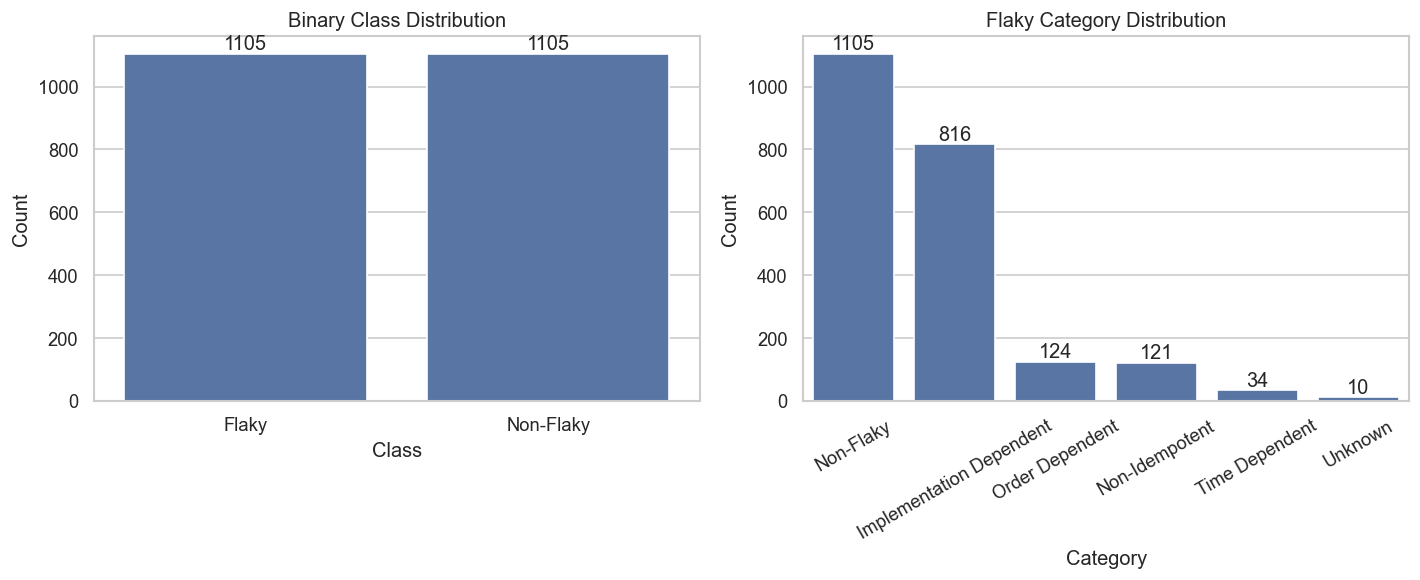

In [119]:
# ============================================================
# Dataset Characterization
# ============================================================

print("=" * 60)
print("DATASET CHARACTERIZATION")
print("=" * 60)

# ------------------------------------------------------------
# Binary Class Distribution
# ------------------------------------------------------------

class_dist = (
    df[["id", "gt_class"]]
    .drop_duplicates()
    .gt_class
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_dist["Percentage"] = (
    class_dist["Count"] / class_dist["Count"].sum() * 100
).round(2)

print("\nBinary Class Distribution")
display(class_dist)

# ------------------------------------------------------------
# Category Distribution
# ------------------------------------------------------------

category_dist = (
    df[["id", "gt_category"]]
    .drop_duplicates()
    .gt_category
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Count")
)

category_dist["Percentage"] = (
    category_dist["Count"] / category_dist["Count"].sum() * 100
).round(2)

print("\nFlaky Category Distribution")
display(category_dist)

# ------------------------------------------------------------
# Visualizations
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Binary classes
sns.barplot(
    data=class_dist,
    x="Class",
    y="Count",
    ax=axes[0],
)

axes[0].set_title("Binary Class Distribution")

for container in axes[0].containers:
    axes[0].bar_label(container)

# Categories

sns.barplot(
    data=category_dist,
    x="Category",
    y="Count",
    ax=axes[1],
)

axes[1].tick_params(axis="x", rotation=30)

axes[1].set_title("Flaky Category Distribution")

for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig01_dataset_class_category_distribution.png", bbox_inches="tight")
plt.show()

### Dataset Summary

The benchmark dataset consists of 2,210 unique test cases evaluated across 12 experimental configurations.

The binary classification task is perfectly balanced, containing 1,105 flaky and 1,105 non-flaky tests.

Among flaky tests, Implementation Dependent failures constitute the majority (73.8% of all flaky tests), while Time Dependent and Unknown failures are relatively rare.

The balanced binary distribution ensures that overall performance metrics are not influenced by class imbalance, whereas category-level analyses should be interpreted considering the unequal distribution of flaky failure types.

# 3. Baseline Performance Evaluation (RQ1)

RQ1 : How accurately can modern LLMs identify flaky tests using only test code?

Hypothesis(H1) : Modern LLMs can identify flaky tests with reasonable predictive performance using only the test implementation, providing a baseline against which context augmentation can be evaluated.

---

### Evaluation Methodology
To establish the baseline performance, only experiments executed without contextual
software artifacts are considered.

Each experiment is evaluated using standard binary classification metrics:

- Accuracy
- Precision
- Recall
- F1-score

In addition, 95% bootstrap confidence intervals are computed for the F1-score to estimate
the uncertainty of each model's performance.

The results presented in this section serve as the reference point for evaluating the impact
of context augmentation in subsequent research questions.

In [120]:
# ============================================================
# Evaluation Functions
# ============================================================


def bootstrap_f1_ci(
    y_true,
    y_pred,
    n_bootstrap=1000,
    confidence=0.95,
    random_state=42,
):
    """
    Compute bootstrap confidence interval for binary F1-score.
    """

    rng = np.random.RandomState(random_state)

    scores = []

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    for _ in range(n_bootstrap):

        idx = rng.randint(0, len(y_true), len(y_true))

        score = f1_score(
            y_true[idx],
            y_pred[idx],
            pos_label=POS_LABEL,
            zero_division=0,
        )

        scores.append(score)

    lower = np.percentile(scores, (1 - confidence) / 2 * 100)
    upper = np.percentile(scores, (1 + confidence) / 2 * 100)

    return lower, upper


def evaluate_binary(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        pos_label=POS_LABEL,
        zero_division=0,
    )

    ci_low, ci_high = bootstrap_f1_ci(
        y_true,
        y_pred,
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "F1 Lower CI": ci_low,
        "F1 Upper CI": ci_high,
    }

print("Evaluation utilities loaded.")

Evaluation utilities loaded.


In [121]:
# ============================================================
# RQ1 Evaluation
# Baseline (Without Context)
# ============================================================

baseline = df[df["context_enabled"] == False].copy()

results = []

for (model, prompt), group in baseline.groupby(
    ["model", "prompt_type"]
):

    metrics = evaluate_binary(
        group["gt_class"],
        group["pred_class"],
    )

    results.append({

        "Model": model,

        "Prompt": PROMPT_LABELS[prompt],

        **metrics

    })

rq1_results = pd.DataFrame(results)

rq1_results

,Model,Prompt,Accuracy,Precision,Recall,F1,F1 Lower CI,F1 Upper CI
0,gemini-3.1-flash-lite,Few-Shot CoT,0.556561,0.845304,0.138462,0.237947,0.206895,0.269722
1,gemini-3.1-flash-lite,Zero-Shot,0.540724,0.826087,0.103167,0.183427,0.155965,0.211943
2,gemini-3.1-flash-lite,Zero-Shot CoT,0.549774,0.866667,0.117647,0.207171,0.176364,0.235871
3,gpt-5-mini,Few-Shot CoT,0.540724,0.881356,0.094118,0.170074,0.141680,0.200481
4,gpt-5-mini,Zero-Shot,0.528054,0.816327,0.072398,0.133001,0.106617,0.159822
5,gpt-5-mini,Zero-Shot CoT,0.538914,0.852459,0.094118,0.169519,0.139366,0.200000


In [122]:
# ============================================================
# Publication Summary Table
# ============================================================

summary = rq1_results.copy()

for col in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
]:

    summary[col] = (summary[col] * 100).round(2)

summary["95% CI"] = summary.apply(

    lambda r:
    f"[{r['F1 Lower CI']*100:.2f}, {r['F1 Upper CI']*100:.2f}]",

    axis=1,
)

summary = summary[
    [
        "Model",
        "Prompt",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "95% CI",
    ]
]

summary = summary.sort_values(
    "F1",
    ascending=False,
).reset_index(drop=True)

display(summary)

summary.to_csv(
    OUTPUT_DIR / "rq1_baseline_summary.csv",
    index=False,
)

print("Summary exported.")

,Model,Prompt,Accuracy,Precision,Recall,F1,95% CI
0,gemini-3.1-flash-lite,Few-Shot CoT,55.66,84.53,13.85,23.79,"[20.69, 26.97]"
1,gemini-3.1-flash-lite,Zero-Shot CoT,54.98,86.67,11.76,20.72,"[17.64, 23.59]"
2,gemini-3.1-flash-lite,Zero-Shot,54.07,82.61,10.32,18.34,"[15.60, 21.19]"
3,gpt-5-mini,Few-Shot CoT,54.07,88.14,9.41,17.01,"[14.17, 20.05]"
4,gpt-5-mini,Zero-Shot CoT,53.89,85.25,9.41,16.95,"[13.94, 20.00]"
5,gpt-5-mini,Zero-Shot,52.81,81.63,7.24,13.30,"[10.66, 15.98]"


Summary exported.


## 3.0.1 Supplementary Category-Level Baseline Metrics

RQ1 primarily uses binary flaky-vs-non-flaky metrics to match the research hypothesis. Since category annotations are available, this supplementary analysis reports category classification quality for the same baseline experiments.

In [123]:
# ============================================================
# RQ1 Supplementary: Baseline Category-Level Metrics
# ============================================================

rq1_category_rows = []

for (model, prompt), group in baseline.groupby(["model", "prompt_type"]):

    category_accuracy = accuracy_score(
        group["gt_category"],
        group["pred_category"],
    )

    category_macro_f1 = f1_score(
        group["gt_category"],
        group["pred_category"],
        average="macro",
        zero_division=0,
    )

    rq1_category_rows.append({
        "Model": model,
        "Prompt": PROMPT_LABELS[prompt],
        "Category Accuracy": category_accuracy,
        "Category Macro F1": category_macro_f1,
    })

rq1_category_results = pd.DataFrame(rq1_category_rows)

rq1_category_summary = rq1_category_results.copy()
rq1_category_summary["Category Accuracy"] = (
    rq1_category_summary["Category Accuracy"] * 100
).round(2)
rq1_category_summary["Category Macro F1"] = (
    rq1_category_summary["Category Macro F1"] * 100
).round(2)

rq1_category_summary = rq1_category_summary.sort_values(
    "Category Accuracy",
    ascending=False,
).reset_index(drop=True)

display(rq1_category_summary)

rq1_category_summary.to_csv(
    OUTPUT_DIR / "rq1_baseline_category_summary.csv",
    index=False,
)

print("Category baseline summary exported.")

,Model,Prompt,Category Accuracy,Category Macro F1
0,gpt-5-mini,Zero-Shot CoT,52.71,20.36
1,gpt-5-mini,Few-Shot CoT,52.53,22.53
2,gemini-3.1-flash-lite,Zero-Shot CoT,52.08,20.45
3,gpt-5-mini,Zero-Shot,51.90,20.37
4,gemini-3.1-flash-lite,Zero-Shot,51.58,20.24
5,gemini-3.1-flash-lite,Few-Shot CoT,50.45,17.74


Category baseline summary exported.


>Without contextual software information, frontier LLMs exhibit high precision but extremely low recall, indicating a strong bias toward predicting tests as non-flaky.

both models are extremely conservative classifiers. They rarely predict Flaky. When they do they are usually correct. But they miss most flaky tests.

## 3.1 Prediction Bias Analysis

The performance metrics indicate an unusual pattern:

- High Precision
- Low Recall

This suggests that the models may be conservative when predicting the Flaky class.

To verify this hypothesis, we analyze the prediction distribution of each experiment.

For every experiment, we compare:

- Actual number of Flaky tests
- Predicted number of Flaky tests
- Predicted number of Non-Flaky tests

This analysis helps explain the behaviour behind the observed evaluation metrics rather than simply reporting them.


In [124]:
# ============================================================
# Prediction Bias Analysis
# ============================================================

bias_results = []

for (model, prompt), group in baseline.groupby(
    ["model", "prompt_type"]
):

    total = len(group)

    actual_flaky = (group["gt_class"] == POS_LABEL).sum()
    actual_non_flaky = (group["gt_class"] == NEG_LABEL).sum()

    predicted_flaky = (group["pred_class"] == POS_LABEL).sum()
    predicted_non_flaky = (group["pred_class"] == NEG_LABEL).sum()

    bias_results.append({

        "Model": model,

        "Prompt": PROMPT_LABELS[prompt],

        "Actual Flaky": actual_flaky,

        "Predicted Flaky": predicted_flaky,

        "Actual Non-Flaky": actual_non_flaky,

        "Predicted Non-Flaky": predicted_non_flaky,

        "Predicted Flaky Rate (%)":
            round(predicted_flaky / total * 100, 2),

        "Prediction Bias Ratio":
            round(predicted_flaky / actual_flaky, 3)

    })

bias_df = pd.DataFrame(bias_results)

display(bias_df)

,Model,Prompt,Actual Flaky,Predicted Flaky,Actual Non-Flaky,Predicted Non-Flaky,Predicted Flaky Rate (%),Prediction Bias Ratio
0,gemini-3.1-flash-lite,Few-Shot CoT,1105,181,1105,2029,8.19,0.164
1,gemini-3.1-flash-lite,Zero-Shot,1105,138,1105,2072,6.24,0.125
2,gemini-3.1-flash-lite,Zero-Shot CoT,1105,150,1105,2060,6.79,0.136
3,gpt-5-mini,Few-Shot CoT,1105,118,1105,2092,5.34,0.107
4,gpt-5-mini,Zero-Shot,1105,98,1105,2112,4.43,0.089
5,gpt-5-mini,Zero-Shot CoT,1105,122,1105,2088,5.52,0.110


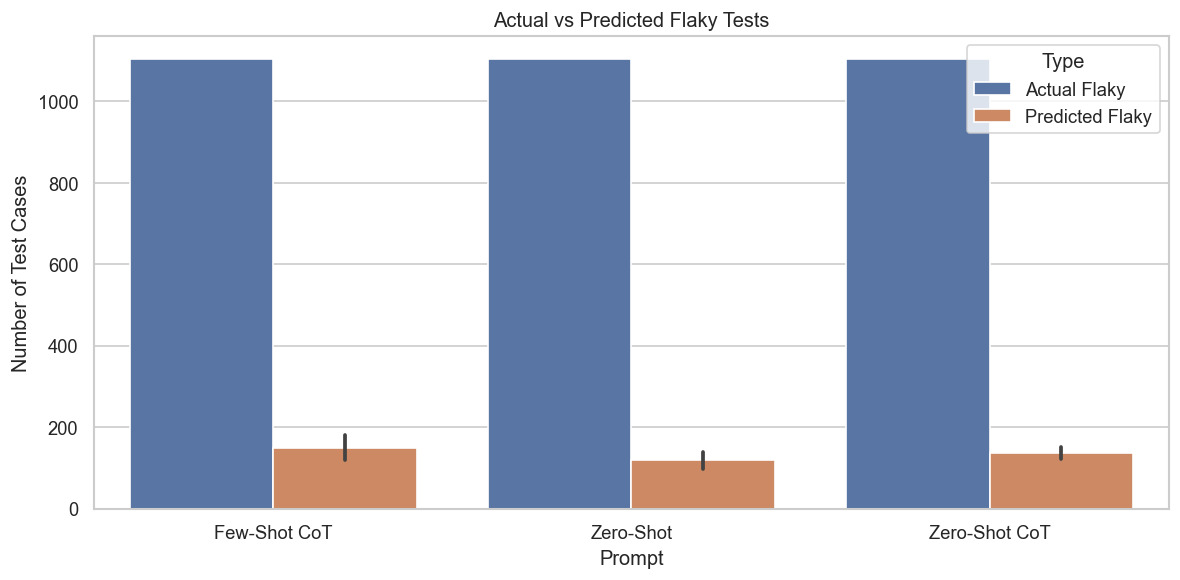

In [125]:
# ============================================================
# Prediction Distribution
# ============================================================

plot_df = bias_df.melt(

    id_vars=["Model", "Prompt"],

    value_vars=[
        "Actual Flaky",
        "Predicted Flaky"
    ],

    var_name="Type",

    value_name="Count"

)

plt.figure(figsize=(10,5))

sns.barplot(

    data=plot_df,

    x="Prompt",

    y="Count",

    hue="Type",

)

plt.title("Actual vs Predicted Flaky Tests")

plt.ylabel("Number of Test Cases")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "fig02_actual_vs_predicted_flaky.png", bbox_inches="tight")

plt.show()

### Key Observations

- Both LLMs demonstrate a strong conservative prediction strategy, labelling only 4–8% of test cases as flaky despite 50% of the benchmark consisting of flaky tests.
- Among the evaluated prompting strategies, Few-Shot CoT consistently achieves the strongest baseline performance when contextual information is unavailable.
- Gemini consistently predicts more flaky tests than GPT-5 Mini, resulting in higher recall while maintaining comparable precision.
- Reasoning-based prompting provides a consistent but modest improvement over direct zero-shot prompting.


## 3.2 Error Analysis

While aggregate performance metrics summarize overall classification quality, they do not
reveal the types of mistakes made by the models.

To better understand model behaviour, we analyze the confusion matrix components for each
baseline experiment:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

This analysis identifies whether the models primarily suffer from:

- missing flaky tests (False Negatives), or
- incorrectly labelling non-flaky tests as flaky (False Positives).

Understanding these error patterns provides insight into the limitations of test-code-only
classification and establishes a baseline for evaluating context augmentation.


In [126]:
# ============================================================
# Confusion Matrix Analysis
# ============================================================

error_results = []

for (model, prompt), group in baseline.groupby(
    ["model", "prompt_type"]
):

    tn, fp, fn, tp = confusion_matrix(
        group["gt_class"],
        group["pred_class"],
        labels=[NEG_LABEL, POS_LABEL],
    ).ravel()

    error_results.append({

        "Model": model,

        "Prompt": PROMPT_LABELS[prompt],

        "TP": tp,

        "TN": tn,

        "FP": fp,

        "FN": fn,

        "False Negative Rate (%)":
            round(fn / (fn + tp) * 100, 2),

        "False Positive Rate (%)":
            round(fp / (fp + tn) * 100, 2),

    })

error_df = pd.DataFrame(error_results)

display(error_df)

,Model,Prompt,TP,TN,FP,FN,False Negative Rate (%),False Positive Rate (%)
0,gemini-3.1-flash-lite,Few-Shot CoT,153,1077,28,952,86.15,2.53
1,gemini-3.1-flash-lite,Zero-Shot,114,1081,24,991,89.68,2.17
2,gemini-3.1-flash-lite,Zero-Shot CoT,130,1085,20,975,88.24,1.81
3,gpt-5-mini,Few-Shot CoT,104,1091,14,1001,90.59,1.27
4,gpt-5-mini,Zero-Shot,80,1087,18,1025,92.76,1.63
5,gpt-5-mini,Zero-Shot CoT,104,1087,18,1001,90.59,1.63


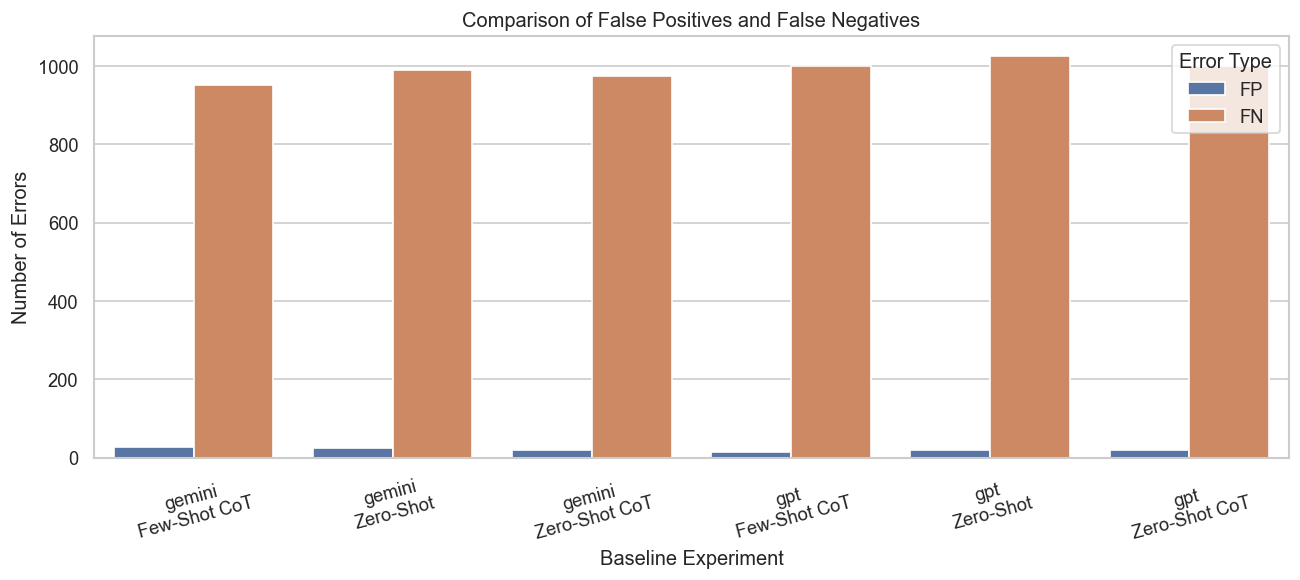

In [127]:
# ============================================================
# Error Type Comparison
# ============================================================

plot_df = error_df.melt(

    id_vars=["Model", "Prompt"],

    value_vars=["FP", "FN"],

    var_name="Error Type",

    value_name="Count",

)

plot_df["Experiment"] = (
    plot_df["Model"].str.replace("-3.1-flash-lite", "", regex=False)
                     .str.replace("-5-mini", "", regex=False)
    + "\n"
    + plot_df["Prompt"]
)

plt.figure(figsize=(11,5))

sns.barplot(

    data=plot_df,

    x="Experiment",

    y="Count",

    hue="Error Type",

)

plt.title("Comparison of False Positives and False Negatives")

plt.ylabel("Number of Errors")

plt.xlabel("Baseline Experiment")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(FIGURE_DIR / "fig03_baseline_fp_fn_comparison.png", bbox_inches="tight")

plt.show()

* Test code alone is insufficient for reliable flaky test identification because LLMs systematically under-identify flaky tests.

* High precision (82–88%) indicates that when LLMs predict a test as flaky, the prediction is usually correct.

* Very low recall (7–14%) shows that most actual flaky tests remain undetected.

* False negatives (952–1025) greatly exceed false positives (14–28), confirming that the primary limitation is missed flaky tests rather than false alarms.

* Gemini consistently predicts more flaky tests than GPT-5 Mini, resulting in higher recall while maintaining similarly low false positive rates.

* Few-Shot CoT improves baseline performance primarily by recovering additional flaky tests rather than reducing false positives.

# 4. Context Augmentation Analysis (RQ2)

RQ2 : Does context augmentation improve flaky test identification?

Hypothesis (H2) : Providing contextual software artifacts enables LLMs to identify flaky tests more accurately than using test code alone.

---

### Evaluation Methodology

Each baseline experiment is paired with its corresponding context-augmented experiment.
The comparison is performed under identical conditions:

- Same model
- Same prompting strategy
- Same benchmark dataset

For each pair, we evaluate:

- Change in Accuracy
- Change in Precision
- Change in Recall
- Change in F1-score

Subsequent sections investigate whether the observed improvements are statistically significant and explain the behavioural changes introduced by contextual software artifacts.


In [128]:
# ============================================================
# Pair Baseline and Context Experiments
# ============================================================

comparison_results = []

for model in MODELS:

    for prompt in PROMPT_TYPES:

        base = df[
            (df.model == model)
            & (df.prompt_type == prompt)
            & (~df.context_enabled)
        ]

        context = df[
            (df.model == model)
            & (df.prompt_type == prompt)
            & (df.context_enabled)
        ]

        assert len(base) == len(context)

        base_metrics = evaluate_binary(
            base.gt_class,
            base.pred_class,
        )

        context_metrics = evaluate_binary(
            context.gt_class,
            context.pred_class,
        )

        comparison_results.append({

            "Model": model,

            "Prompt": PROMPT_LABELS[prompt],

            "Baseline F1": base_metrics["F1"],

            "Context F1": context_metrics["F1"],

            "Δ F1":
                context_metrics["F1"] -
                base_metrics["F1"],

            "Baseline Recall": base_metrics["Recall"],

            "Context Recall": context_metrics["Recall"],

            "Δ Recall":
                context_metrics["Recall"] -
                base_metrics["Recall"],

            "Baseline Precision":
                base_metrics["Precision"],

            "Context Precision":
                context_metrics["Precision"],

            "Δ Precision":
                context_metrics["Precision"] -
                base_metrics["Precision"],

        })

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Model,Prompt,Baseline F1,Context F1,Δ F1,Baseline Recall,Context Recall,Δ Recall,Baseline Precision,Context Precision,Δ Precision
0,gemini-3.1-flash-lite,Zero-Shot,0.183427,0.750578,0.567151,0.103167,0.733937,0.630769,0.826087,0.767992,-0.058095
1,gemini-3.1-flash-lite,Zero-Shot CoT,0.207171,0.711133,0.503962,0.117647,0.656109,0.538462,0.866667,0.776231,-0.090435
2,gemini-3.1-flash-lite,Few-Shot CoT,0.237947,0.513694,0.275747,0.138462,0.381900,0.243439,0.845304,0.784387,-0.060917
3,gpt-5-mini,Zero-Shot,0.133001,0.673415,0.540414,0.072398,0.571946,0.499548,0.816327,0.818653,0.002326
4,gpt-5-mini,Zero-Shot CoT,0.169519,0.683905,0.514386,0.094118,0.586425,0.492308,0.852459,0.820253,-0.032206
5,gpt-5-mini,Few-Shot CoT,0.170074,0.586457,0.416383,0.094118,0.438914,0.344796,0.881356,0.883424,0.002068


In [129]:
summary = comparison_df.copy()

for col in summary.columns:

    if "Baseline" in col or "Context" in col or "Δ" in col:

        summary[col] = (summary[col] * 100).round(2)

summary = summary.sort_values(
    "Δ F1",
    ascending=False,
)

display(summary)

,Model,Prompt,Baseline F1,Context F1,Δ F1,Baseline Recall,Context Recall,Δ Recall,Baseline Precision,Context Precision,Δ Precision
0,gemini-3.1-flash-lite,Zero-Shot,18.34,75.06,56.72,10.32,73.39,63.08,82.61,76.80,-5.81
3,gpt-5-mini,Zero-Shot,13.30,67.34,54.04,7.24,57.19,49.95,81.63,81.87,0.23
4,gpt-5-mini,Zero-Shot CoT,16.95,68.39,51.44,9.41,58.64,49.23,85.25,82.03,-3.22
1,gemini-3.1-flash-lite,Zero-Shot CoT,20.72,71.11,50.40,11.76,65.61,53.85,86.67,77.62,-9.04
5,gpt-5-mini,Few-Shot CoT,17.01,58.65,41.64,9.41,43.89,34.48,88.14,88.34,0.21
2,gemini-3.1-flash-lite,Few-Shot CoT,23.79,51.37,27.57,13.85,38.19,24.34,84.53,78.44,-6.09


## 4.0.1 Supplementary Category-Level Impact of Context

In addition to binary metrics, this section quantifies how context augmentation changes category-level classification accuracy for each paired experiment.

In [130]:
# ============================================================
# RQ2 Supplementary: Category-Level Improvement from Context
# ============================================================

rq2_category_comparison_rows = []

for model in MODELS:

    for prompt in PROMPT_TYPES:

        base = df[
            (df.model == model)
            & (df.prompt_type == prompt)
            & (~df.context_enabled)
        ]

        context = df[
            (df.model == model)
            & (df.prompt_type == prompt)
            & (df.context_enabled)
        ]

        base_category_acc = accuracy_score(
            base["gt_category"],
            base["pred_category"],
        )
        context_category_acc = accuracy_score(
            context["gt_category"],
            context["pred_category"],
        )

        rq2_category_comparison_rows.append({
            "Model": model,
            "Prompt": PROMPT_LABELS[prompt],
            "Baseline Category Accuracy": base_category_acc,
            "Context Category Accuracy": context_category_acc,
            "Δ Category Accuracy": context_category_acc - base_category_acc,
        })

rq2_category_comparison = pd.DataFrame(rq2_category_comparison_rows)

rq2_category_summary = rq2_category_comparison.copy()

for col in [
    "Baseline Category Accuracy",
    "Context Category Accuracy",
    "Δ Category Accuracy",
]:
    rq2_category_summary[col] = (rq2_category_summary[col] * 100).round(2)

rq2_category_summary = rq2_category_summary.sort_values(
    "Δ Category Accuracy",
    ascending=False,
).reset_index(drop=True)

display(rq2_category_summary)

rq2_category_summary.to_csv(
    OUTPUT_DIR / "rq2_context_category_comparison.csv",
    index=False,
)

print("Category context-comparison summary exported.")

,Model,Prompt,Baseline Category Accuracy,Context Category Accuracy,Δ Category Accuracy
0,gpt-5-mini,Zero-Shot,51.90,68.10,16.20
1,gpt-5-mini,Zero-Shot CoT,52.71,67.87,15.16
2,gpt-5-mini,Few-Shot CoT,52.53,65.38,12.85
3,gemini-3.1-flash-lite,Zero-Shot,51.58,54.52,2.94
4,gemini-3.1-flash-lite,Zero-Shot CoT,52.08,54.16,2.08
5,gemini-3.1-flash-lite,Few-Shot CoT,50.45,51.40,0.95


Category context-comparison summary exported.


* Context augmentation consistently improved classification performance across all evaluated models and prompting strategies.

* The primary contribution of context augmentation is a substantial increase in the model's ability to identify flaky tests (Recall).

* Context augmentation improves flaky test detection without substantially increasing false 
alarms.

* Zero-Shot - Huge improvement.(18% -> 75%) but Few-Shot Smaller improvement.(24% -> 51%).Because Few-Shot CoT already provides additional guidance. So there is less room for context to help. This is an observation worth investigating further rather than presenting as a confirmed conclusion.

> RQ2 demonstrates that context augmentation substantially improves flaky test identification by enabling LLMs to recover a large proportion of previously missed flaky tests while maintaining high precision. The improvement is consistent across all evaluated models and prompting strategies, indicating that contextual software artifacts effectively address the primary limitation observed in the baseline experiments.

## 4.1 Prediction Transition Analysis

Overall performance metrics demonstrate that context augmentation substantially improves
classification performance. However, aggregate metrics do not explain how these
improvements occur.

To better understand the effect of contextual software artifacts, we compare the prediction
made for every individual test case before and after context augmentation.

Each prediction is classified into one of four transition types:

- False Negative → True Positive (Recovered Flaky Test)
- True Positive → False Negative (Lost Correct Detection)
- False Positive → True Negative (Corrected False Alarm)
- True Negative → False Positive (New False Alarm)

This analysis provides insight into the behavioural changes introduced by context
augmentation beyond conventional performance metrics.


In [131]:
# ============================================================
# Prediction Transition Analysis
# ============================================================

transition_results = []

for model in MODELS:

    for prompt in PROMPT_TYPES:

        base = df[
            (df.model == model)
            & (df.prompt_type == prompt)
            & (~df.context_enabled)
        ].sort_values("id")

        ctx = df[
            (df.model == model)
            & (df.prompt_type == prompt)
            & (df.context_enabled)
        ].sort_values("id")

        merged = base[
            ["id", "gt_class", "pred_class"]
        ].rename(
            columns={"pred_class": "baseline_pred"}
        ).merge(
            ctx[
                ["id", "pred_class"]
            ].rename(
                columns={"pred_class": "context_pred"}
            ),
            on="id",
        )

        recovered = 0
        regressed = 0
        corrected_fp = 0
        new_fp = 0

        for _, row in merged.iterrows():

            gt = row.gt_class
            b = row.baseline_pred
            c = row.context_pred

            # FN -> TP
            if (
                gt == POS_LABEL
                and b != POS_LABEL
                and c == POS_LABEL
            ):
                recovered += 1

            # TP -> FN
            elif (
                gt == POS_LABEL
                and b == POS_LABEL
                and c != POS_LABEL
            ):
                regressed += 1

            # FP -> TN
            elif (
                gt == NEG_LABEL
                and b == POS_LABEL
                and c != POS_LABEL
            ):
                corrected_fp += 1

            # TN -> FP
            elif (
                gt == NEG_LABEL
                and b != POS_LABEL
                and c == POS_LABEL
            ):
                new_fp += 1

        transition_results.append({

            "Model": model,

            "Prompt": PROMPT_LABELS[prompt],

            "Recovered Flaky (FN→TP)": recovered,

            "Lost Detection (TP→FN)": regressed,

            "Corrected False Alarm (FP→TN)": corrected_fp,

            "New False Alarm (TN→FP)": new_fp,

        })

transition_df = pd.DataFrame(transition_results)

display(transition_df)

,Model,Prompt,Recovered Flaky (FN→TP),Lost Detection (TP→FN),Corrected False Alarm (FP→TN),New False Alarm (TN→FP)
0,gemini-3.1-flash-lite,Zero-Shot,715,18,5,226
1,gemini-3.1-flash-lite,Zero-Shot CoT,621,26,7,196
2,gemini-3.1-flash-lite,Few-Shot CoT,312,43,18,106
3,gpt-5-mini,Zero-Shot,568,16,14,136
4,gpt-5-mini,Zero-Shot CoT,570,26,15,139
5,gpt-5-mini,Few-Shot CoT,425,44,12,62


* Context augmentation primarily improves classification by recovering a large number of previously missed flaky tests.

* Across all evaluated configurations, the number of recovered flaky tests substantially exceeds the number of lost detections, indicating that context consistently corrects more errors than it introduces.

* The modest reduction in precision observed after context augmentation is explained by the introduction of some new false alarms, which represent a trade-off for the much larger improvement in flaky test detection.

* The prediction transition analysis demonstrates that context augmentation changes the decision-making behaviour of LLMs by converting previously missed flaky tests into correct detections rather than merely increasing the number of flaky predictions indiscriminately

## 4.2 Statistical Significance Analysis

While the previous analyses demonstrate substantial improvements in performance after
context augmentation, it is important to determine whether these improvements are
statistically significant.

Because the baseline and context-augmented models are evaluated on the same set of test
instances, their predictions are paired. Therefore, McNemar's test is employed to compare
the two classifiers for each model and prompting strategy.

The null hypothesis (H₀) states that both classifiers have the same error rate.

The alternative hypothesis (H₁) states that context augmentation changes the error rate,
indicating a statistically significant improvement in classification performance.


In [132]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [133]:
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

results = []

for model in MODELS:

    for prompt in PROMPT_TYPES:

        base = df[
            (df.model == model)
            & (df.prompt_type == prompt)
            & (~df.context_enabled)
        ].sort_values("id")

        ctx = df[
            (df.model == model)
            & (df.prompt_type == prompt)
            & (df.context_enabled)
        ].sort_values("id")

        merged = base[
            ["id", "gt_class", "correct"]
        ].rename(
            columns={"correct": "baseline_correct"}
        ).merge(
            ctx[
                ["id", "correct"]
            ].rename(
                columns={"correct": "context_correct"}
            ),
            on="id"
        )

        both_correct = (
            (merged.baseline_correct)
            & (merged.context_correct)
        ).sum()

        baseline_only = (
            (merged.baseline_correct)
            & (~merged.context_correct)
        ).sum()

        context_only = (
            (~merged.baseline_correct)
            & (merged.context_correct)
        ).sum()

        both_wrong = (
            (~merged.baseline_correct)
            & (~merged.context_correct)
        ).sum()

        table = [
            [both_correct, baseline_only],
            [context_only, both_wrong]
        ]

        test = mcnemar(
            table,
            exact=False,
            correction=True
        )

        results.append({

            "Model": model,

            "Prompt": PROMPT_LABELS[prompt],

            "Chi-square": round(test.statistic,3),

            "p-value": test.pvalue,

        })

mcnemar_df = pd.DataFrame(results)

# Correct for running 6 McNemar tests in the same family (Holm-Bonferroni).
_, corrected_p, _, _ = multipletests(
    mcnemar_df["p-value"],
    alpha=0.05,
    method="holm",
)

mcnemar_df["Holm-Corrected p-value"] = corrected_p
mcnemar_df["Significant (α=0.05)"] = mcnemar_df["p-value"] < 0.05
mcnemar_df["Significant (Holm-corrected)"] = mcnemar_df["Holm-Corrected p-value"] < 0.05

display(mcnemar_df)

,Model,Prompt,Chi-square,p-value,Holm-Corrected p-value,Significant (α=0.05),Significant (Holm-corrected)
0,gemini-3.1-flash-lite,Zero-Shot,234.051,7.797527e-53,3.839504e-52,True,True
1,gemini-3.1-flash-lite,Zero-Shot CoT,192.971,7.144002e-44,1.428800e-43,True,True
2,gemini-3.1-flash-lite,Few-Shot CoT,67.641,1.961541e-16,1.961541e-16,True,True
3,gpt-5-mini,Zero-Shot,250.737,1.793723e-56,1.076234e-55,True,True
4,gpt-5-mini,Zero-Shot CoT,234.081,7.679007e-53,3.839504e-52,True,True
5,gpt-5-mini,Few-Shot CoT,200.552,1.582224e-45,4.746671e-45,True,True


>Null Hypothesis (H₀)

* Context augmentation does not change the classification performance. Any observed differences are due to chance.

>Alternative Hypothesis (H₁)

* Context augmentation changes the classification performance.

> p < 0.05 means Reject H₀.

>Context augmentation produces statistically significant improvements across every evaluated model and prompting strategy.

**RQ2 Conclusion.** Context augmentation significantly improves flaky test identification across all evaluated LLMs and prompting strategies. The improvement is driven primarily by the recovery of previously missed flaky tests while maintaining relatively high precision. McNemar's test confirms that these improvements are statistically significant, indicating that the observed gains are unlikely to have occurred by chance.


## 4.3 Confusion Matrices Across All 12 Experiments

The tables and charts above summarize each experiment using aggregate metrics (accuracy, precision, recall, F1). To see the full outcome distribution at a glance, this section renders the raw binary confusion matrix (Flaky vs Non-Flaky) for every one of the 12 experiments side by side, grouped by model, prompting strategy, and context setting.


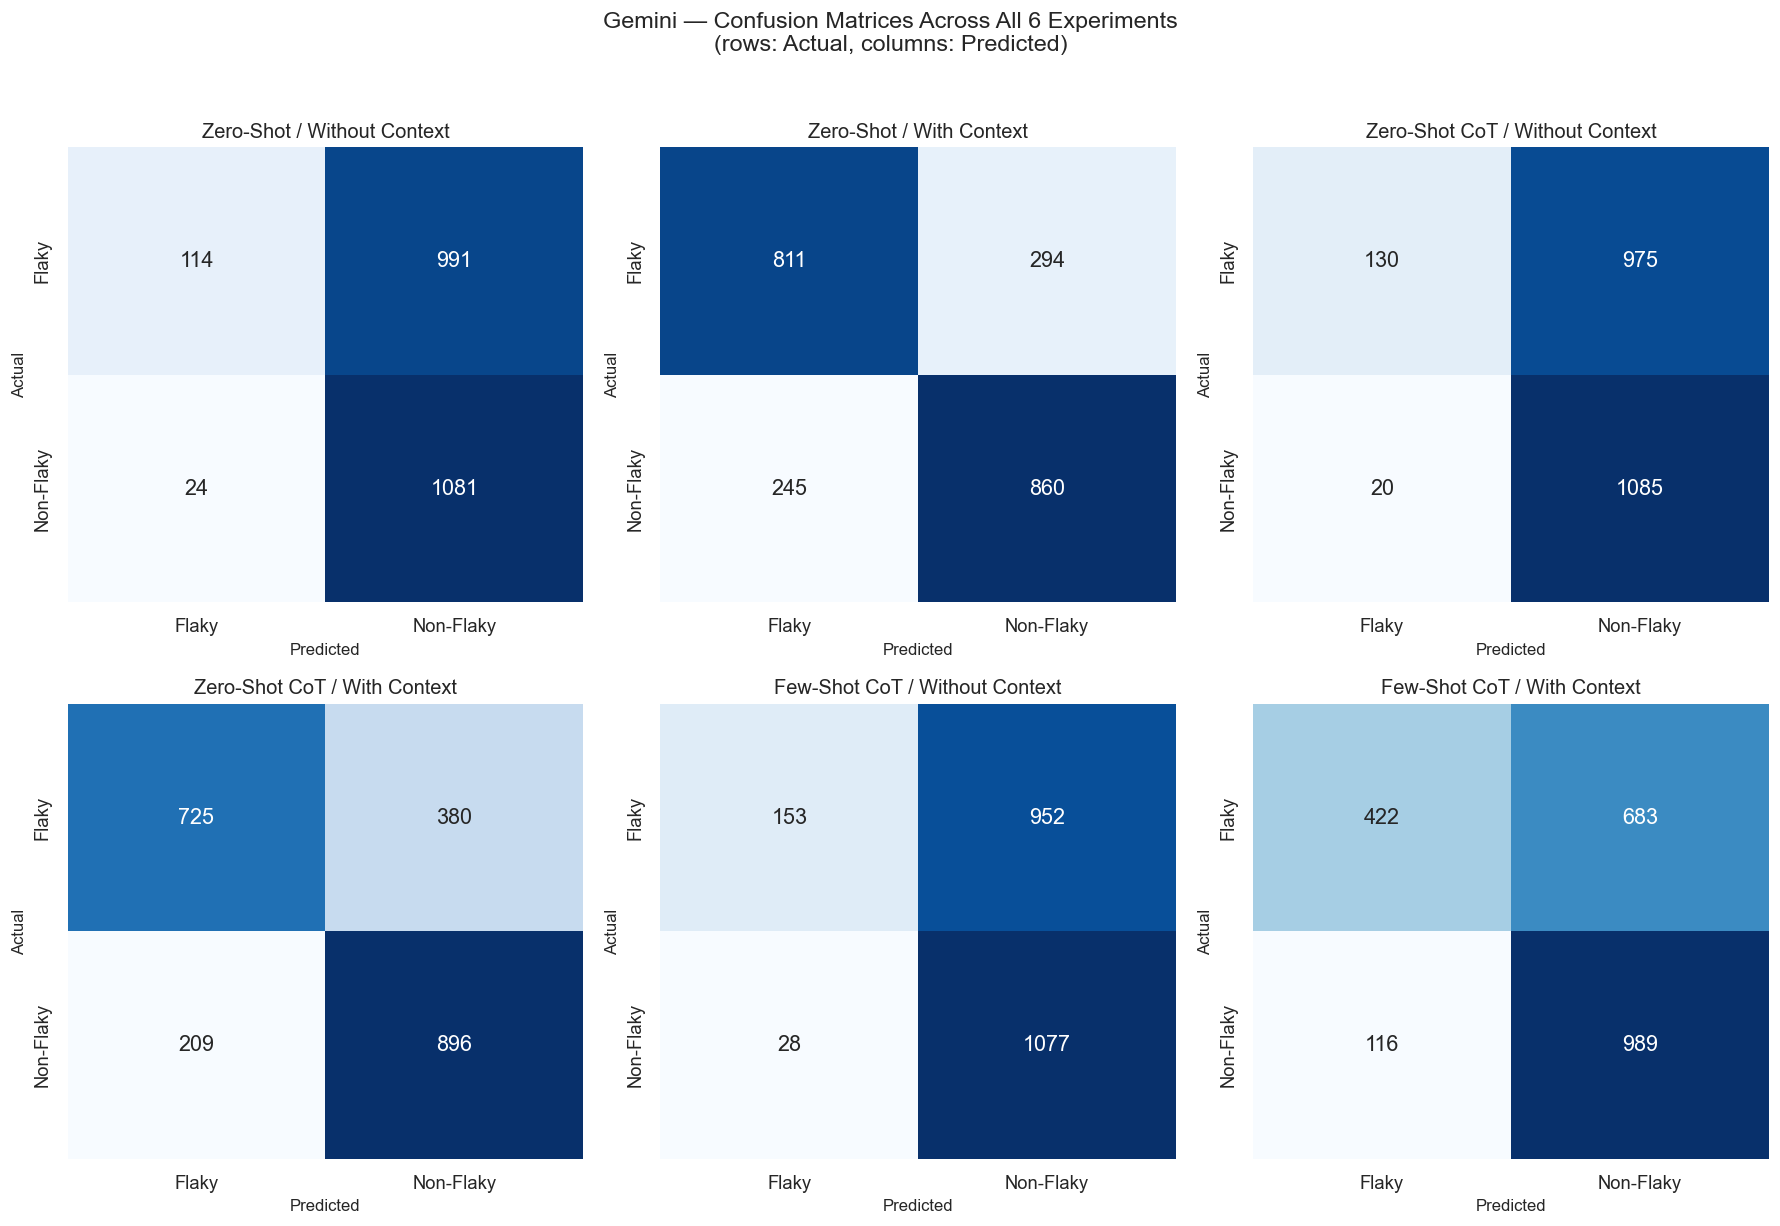

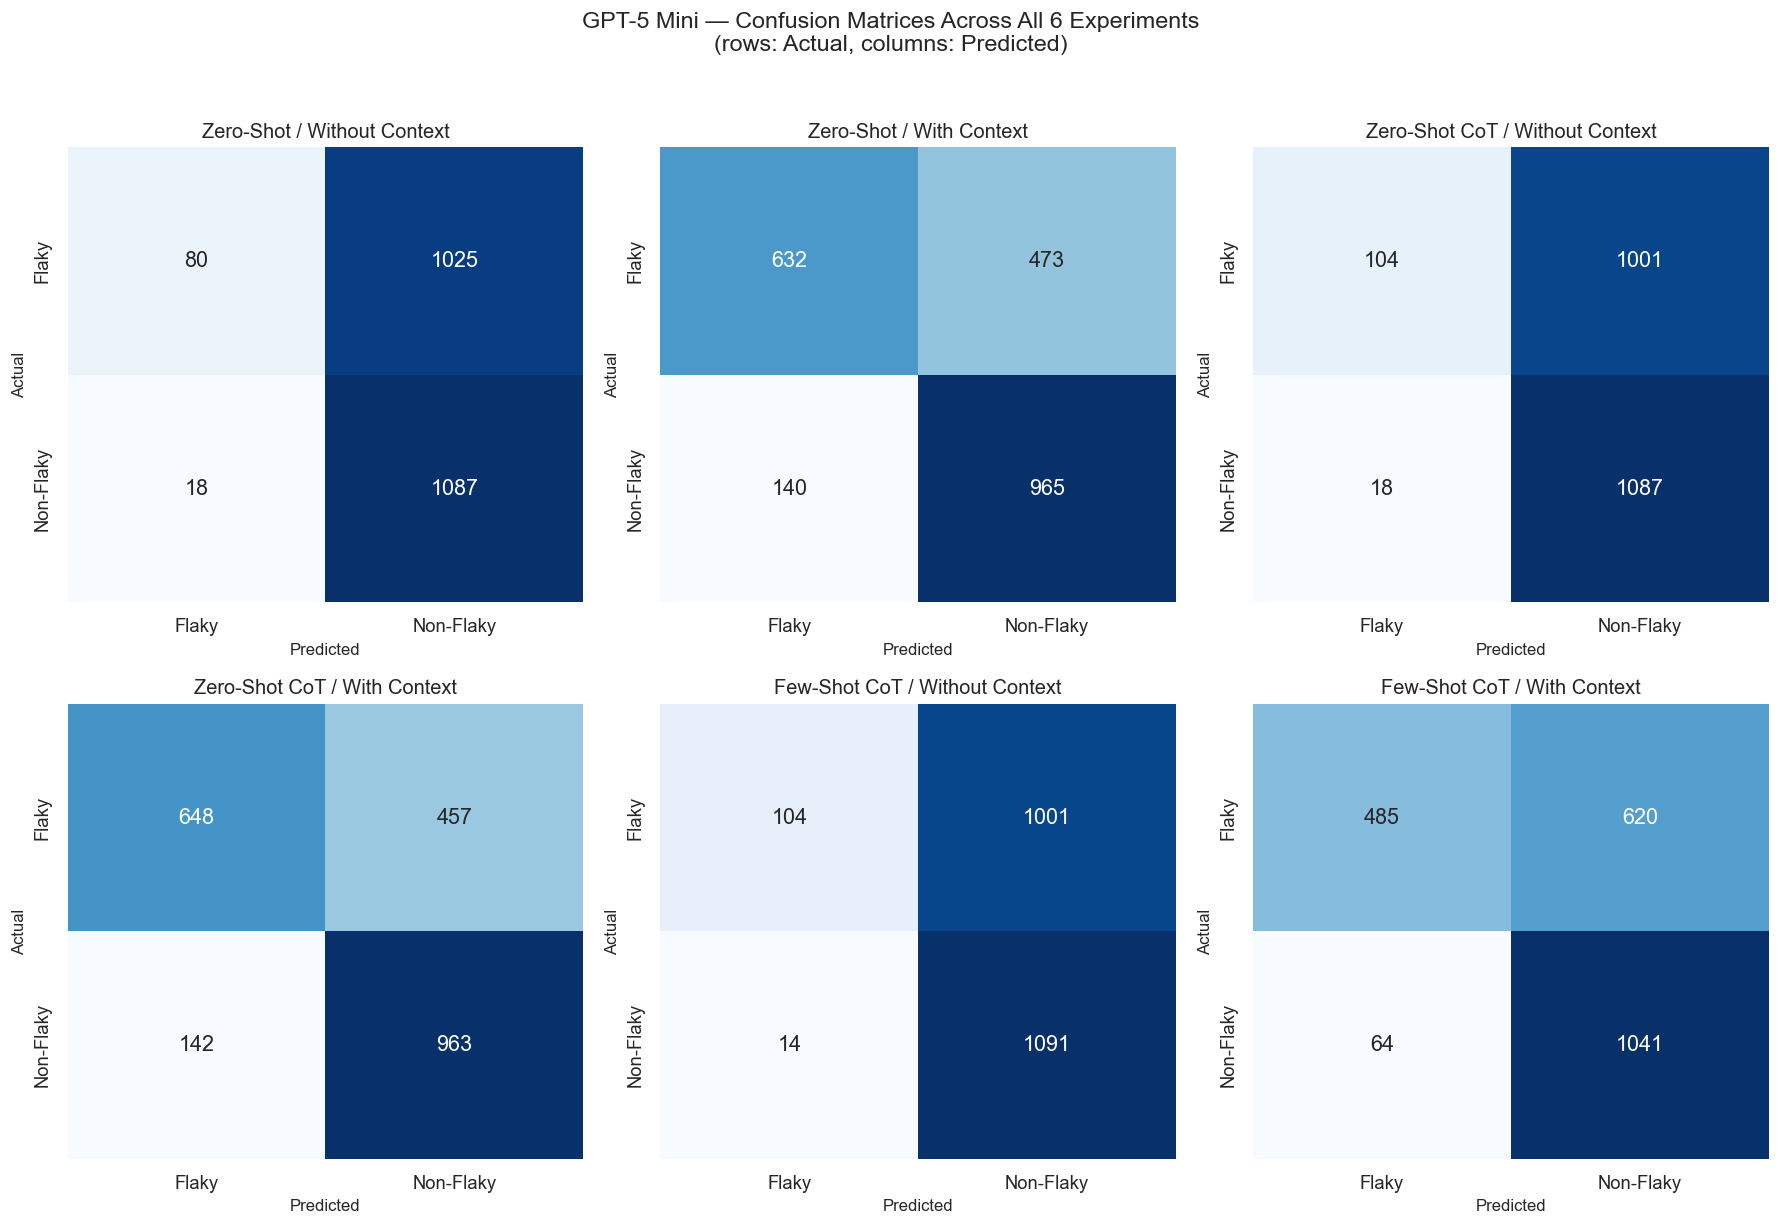

In [134]:
# ============================================================
# Confusion Matrices Across All 12 Experiments
# One figure per model (6 panels each) for readability.
# ============================================================
# MODEL_LABELS is defined once in the Project Configuration cell.

combos = [
    (prompt, context_enabled)
    for prompt in PROMPT_TYPES
    for context_enabled in [False, True]
]

for model in MODELS:

    fig, axes = plt.subplots(2, len(PROMPT_TYPES), figsize=(15, 10))

    for ax, (prompt, context_enabled) in zip(axes.flat, combos):

        group = df[
            (df["model"] == model)
            & (df["prompt_type"] == prompt)
            & (df["context_enabled"] == context_enabled)
        ]

        cm = confusion_matrix(
            group["gt_class"],
            group["pred_class"],
            labels=[POS_LABEL, NEG_LABEL],
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax,
            annot_kws={"fontsize": 13},
            xticklabels=[POS_LABEL, NEG_LABEL],
            yticklabels=[POS_LABEL, NEG_LABEL],
        )

        ctx_label = "With Context" if context_enabled else "Without Context"

        ax.set_title(
            f"{PROMPT_LABELS[prompt]} / {ctx_label}",
            fontsize=12,
        )

        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("Actual", fontsize=10)

    fig.suptitle(
        f"{MODEL_LABELS[model]} — Confusion Matrices Across All 6 Experiments\n"
        "(rows: Actual, columns: Predicted)",
        y=1.02,
        fontsize=14,
    )

    plt.tight_layout()

    model_slug = MODEL_LABELS[model].lower().replace(" ", "_").replace("-", "")

    plt.savefig(
        FIGURE_DIR / f"fig15_confusion_matrices_{model_slug}.png",
        bbox_inches="tight",
    )

    plt.show()


Additional Finding Model-Level Error Pattern

The full grid makes a model-level difference visible that the aggregate metrics only hint at. In every prompting strategy, once context is added, GPT-5 Mini produces fewer false positives than Gemini (140 vs 245 for Zero-Shot, 142 vs 209 for Zero-Shot CoT, 64 vs 116 for Few-Shot CoT), while Gemini recovers more true positives in every case (811 vs 632, 725 vs 648, 422 vs 485 — comparable for Few-Shot CoT). This confirms, at the level of raw counts rather than derived metrics, that GPT-5 Mini remains the more conservative classifier of the two even after context augmentation, trading recall for precision, while Gemini is more willing to flag a test as Flaky when contextual evidence is present.


# 5. Prompt Strategy Evaluation (RQ3)

RQ3 : Which prompting strategy provides the most reliable classification performance?

Hypothesis H3 : Structured reasoning prompts outperform direct Zero-Shot prompting.


Prompt engineering is widely used to improve the reasoning capabilities of Large Language Models. This experiment evaluates three prompting strategies:

- Zero-Shot
- Zero-Shot Chain-of-Thought (CoT)
- Few-Shot Chain-of-Thought (CoT)

The comparison is performed separately for the baseline (test code only) and context-augmented settings to determine how prompting strategy influences flaky test identification performance.


In [135]:
# ============================================================
# RQ3 - Prompt Strategy Performance
# ============================================================

prompt_results = []

for context in [False, True]:

    context_name = (
        "Without Context"
        if not context
        else "With Context"
    )

    for model in MODELS:

        for prompt in PROMPT_TYPES:

            subset = df[
                (df["model"] == model)
                & (df["prompt_type"] == prompt)
                & (df["context_enabled"] == context)
            ]

            metrics = evaluate_binary(
                subset["gt_class"],
                subset["pred_class"]
            )

            prompt_results.append({

                "Context": context_name,

                "Model": model,

                "Prompt": PROMPT_LABELS[prompt],

                "Accuracy":
                    round(metrics["Accuracy"] * 100, 2),

                "Precision":
                    round(metrics["Precision"] * 100, 2),

                "Recall":
                    round(metrics["Recall"] * 100, 2),

                "F1":
                    round(metrics["F1"] * 100, 2)

            })

prompt_df = pd.DataFrame(prompt_results)

display(prompt_df)

,Context,Model,Prompt,Accuracy,Precision,Recall,F1
0,Without Context,gemini-3.1-flash-lite,Zero-Shot,54.07,82.61,10.32,18.34
1,Without Context,gemini-3.1-flash-lite,Zero-Shot CoT,54.98,86.67,11.76,20.72
2,Without Context,gemini-3.1-flash-lite,Few-Shot CoT,55.66,84.53,13.85,23.79
3,Without Context,gpt-5-mini,Zero-Shot,52.81,81.63,7.24,13.30
4,Without Context,gpt-5-mini,Zero-Shot CoT,53.89,85.25,9.41,16.95
5,Without Context,gpt-5-mini,Few-Shot CoT,54.07,88.14,9.41,17.01
6,With Context,gemini-3.1-flash-lite,Zero-Shot,75.61,76.80,73.39,75.06
7,With Context,gemini-3.1-flash-lite,Zero-Shot CoT,73.35,77.62,65.61,71.11
8,With Context,gemini-3.1-flash-lite,Few-Shot CoT,63.85,78.44,38.19,51.37
9,With Context,gpt-5-mini,Zero-Shot,72.26,81.87,57.19,67.34


In [136]:
# ============================================================
# Prompt Performance WITHOUT Context
# ============================================================

baseline_prompt_table = (
    prompt_df[
        prompt_df["Context"] == "Without Context"
    ]
    .pivot(
        index="Prompt",
        columns="Model",
        values="F1"
    )
)

print("=" * 70)
print("Prompt Performance (Without Context)")
print("=" * 70)

display(baseline_prompt_table.round(2))


# ============================================================
# Prompt Performance WITH Context
# ============================================================

context_prompt_table = (
    prompt_df[
        prompt_df["Context"] == "With Context"
    ]
    .pivot(
        index="Prompt",
        columns="Model",
        values="F1"
    )
)

print("=" * 70)
print("Prompt Performance (With Context)")
print("=" * 70)

display(context_prompt_table.round(2))

Prompt Performance (Without Context)


Model,gemini-3.1-flash-lite,gpt-5-mini
Prompt,,
Few-Shot CoT,23.79,17.01
Zero-Shot,18.34,13.30
Zero-Shot CoT,20.72,16.95


Prompt Performance (With Context)


Model,gemini-3.1-flash-lite,gpt-5-mini
Prompt,,
Few-Shot CoT,51.37,58.65
Zero-Shot,75.06,67.34
Zero-Shot CoT,71.11,68.39


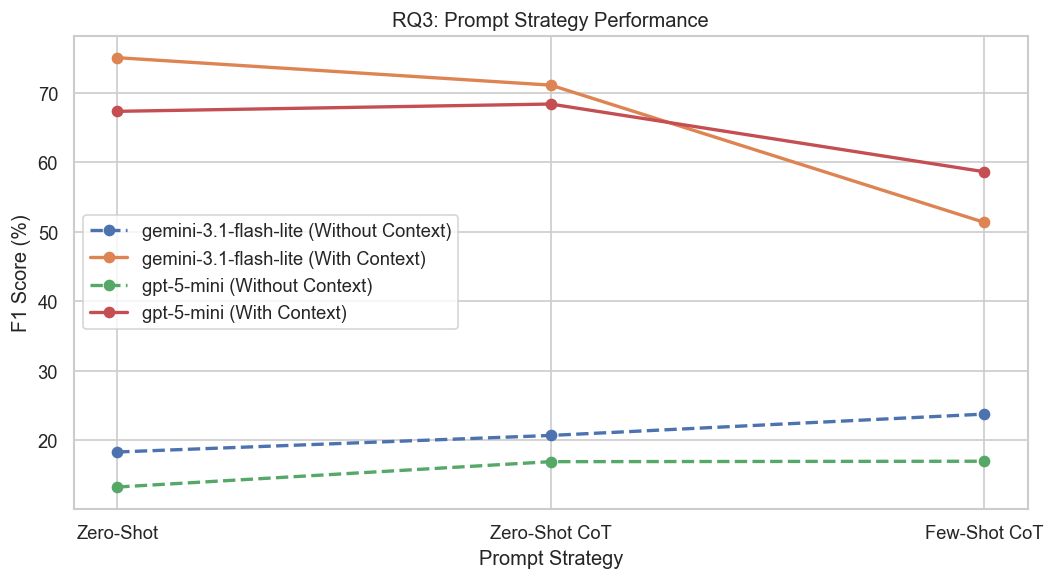

In [137]:
# ============================================================
# RQ3 Figure
# F1 Performance Across Prompt Strategies
# ============================================================

prompt_order = [
    "Zero-Shot",
    "Zero-Shot CoT",
    "Few-Shot CoT"
]

fig, ax = plt.subplots(figsize=(9,5))

for model in MODELS:

    for context, linestyle in zip(
        ["Without Context", "With Context"],
        ["--", "-"]
    ):

        subset = prompt_df[
            (prompt_df["Model"] == model)
            & (prompt_df["Context"] == context)
        ].copy()

        subset["Prompt"] = pd.Categorical(
            subset["Prompt"],
            categories=prompt_order,
            ordered=True
        )

        subset = subset.sort_values("Prompt")

        ax.plot(
            subset["Prompt"],
            subset["F1"],
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            label=f"{model} ({context})"
        )

ax.set_ylabel("F1 Score (%)")
ax.set_xlabel("Prompt Strategy")
ax.set_title("RQ3: Prompt Strategy Performance")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig04_rq3_prompt_strategy_f1.png", bbox_inches="tight")
plt.show()

### RQ3 Findings

**Structured prompting improves baseline classification.**
When only test code is available, both LLMs benefit from structured reasoning prompts. Few-Shot CoT achieved the highest F1 score for Gemini (23.79%) and GPT (17.01%), supporting H3 under the baseline setting.

**Prompt effectiveness changes after context augmentation.**
After contextual software artifacts are introduced, the ranking of prompting strategies changes substantially. Gemini achieved its highest F1 score using Zero-Shot prompting (75.06%), while GPT achieved its best performance using Zero-Shot CoT (68.39%). In both models, Few-Shot CoT no longer achieved the best performance.

**Few-Shot CoT is not consistently the most reliable prompting strategy.**
Although Few-Shot CoT produced the strongest baseline performance, it became the weakest-performing strategy after context augmentation for both evaluated models. This indicates that its effectiveness depends on the available input information rather than being universally superior.

**Contextual software artifacts reduce the relative benefit of structured prompting.**
The results suggest that rich contextual information provides sufficient evidence for classification, allowing simpler prompting strategies such as Zero-Shot or Zero-Shot CoT to perform as well as or better than more elaborate Few-Shot prompts.

**The observed trend is consistent across different LLMs.**
Although Gemini consistently achieved higher F1 scores than GPT across most experiments, both models exhibited similar changes in prompt ranking after context augmentation. This indicates that the observed behaviour is consistent across two different frontier LLMs evaluated in this study.


>Overall, H3 is only partially supported. Structured reasoning prompts improve flaky test identification when only test code is available. However, after contextual software artifacts are introduced, simpler prompting strategies become equally effective or superior, indicating that the influence of prompt engineering depends on the richness of the available software context.

# 6. Contextual Artefact Contribution (RQ4)

RQ4: Which contextual software artefacts contribute most to correct classifications?

Hypothesis H4: Production code and runtime failure information contribute more than helper methods alone.

### Evaluation Strategy

Unlike RQ2, which evaluated the overall impact of software context, this research question examines how different contextual software artefacts are utilized during successful classifications.

The analysis focuses on the following contextual software artefacts:

- Production Code
- Runtime Failure Log
- Helper Methods

Since Helper Methods are optional and are not available for every test case, their utilization will be interpreted relative to their availability within the dataset.


In [138]:
# ============================================================
# Inspect Context Information Available in Predictions
# ============================================================

context_df = df[df["context_enabled"]].copy()

print("=" * 70)
print("RQ4 DATASET")
print("=" * 70)

print(f"Context-enabled predictions : {len(context_df):,}")
print(f"Correct predictions         : {context_df['correct'].sum():,}")
print(f"Incorrect predictions       : {(~context_df['correct']).sum():,}")

print("\nAvailable Columns")
print("-" * 70)

for col in sorted(context_df.columns):
    print(col)

RQ4 DATASET
Context-enabled predictions : 13,260
Correct predictions         : 9,437
Incorrect predictions       : 3,823

Available Columns
----------------------------------------------------------------------
context_enabled
correct
evidence
experiment
gt_category
gt_class
id
latency_ms
model
pred_category
pred_class
prompt_type
reasoning
test_id


In [139]:
# ============================================================
# Inspect Prediction Structure
# ============================================================

sample = context_df.iloc[0]

print("=" * 70)
print("Sample Prediction")
print("=" * 70)

for key, value in sample.items():

    if isinstance(value, (list, dict)):
        print(f"\n{key}")
        print(value)

    else:
        print(f"{key}: {value}")

Sample Prediction
id: 1
test_id: apollojavaapolloopenapi5344bc4testFindItemsByNamespace
gt_class: Flaky
gt_category: Implementation Dependent
pred_class: Flaky
pred_category: Non-Idempotent
reasoning: The test fails because the order of query parameters ('page' and 'size') in the generated URL is inconsistent. The production code uses a 'params' map (likely a HashMap) in 'OpenApiPathBuilder.buildPath' to construct the query string. Since the iteration order of a HashMap is not guaranteed, the resulting URL string varies between executions, causing the 'assertEquals' check to fail when the actual order differs from the expected hardcoded string.

evidence
['Test Code', 'Failure Log', 'Production Code']
model: gemini-3.1-flash-lite
prompt_type: zero_shot
context_enabled: True
latency_ms: None
experiment: gemini-3.1-flash-lite | Zero-Shot | With Context
correct: True


## 6.1 Contextual Artefact Utilization

This analysis examines which contextual software artefacts were utilized by the LLM during context-enabled predictions. The `evidence` field records the artefacts explicitly referenced in the model's reasoning. Before quantifying utilization, the evidence labels are normalized to ensure consistent naming across all predictions.


In [140]:
# ============================================================
# RQ4 - Inspect Context Artefact Labels
# ============================================================

artifact_counter = Counter()

for evidence in context_df["evidence"]:

    if isinstance(evidence, list):

        artifact_counter.update(evidence)

print("=" * 70)
print("Raw Context Artefact Labels")
print("=" * 70)

artifact_df = (
    pd.DataFrame(
        artifact_counter.items(),
        columns=["Artefact", "Frequency"]
    )
    .sort_values("Frequency", ascending=False)
    .reset_index(drop=True)
)

display(artifact_df)

Raw Context Artefact Labels


,Artefact,Frequency
0,Test Code,12744
1,Failure Log,12627
2,Production Code,8211
3,Helper Methods,4838
4,Production Code: com.j256.ormlite.logger.BaseL...,89
...,...,...
4350,Production Code: WorkflowActionBean (setStartD...,1
4351,Test Code (emitTestHelper): uses Thread.sleep(...,1
4352,Helper Methods (emitTestHelper logic): starts ...,1
4353,Production Code (com.datatorrent.stram.engine....,1


### Artefact Label Normalization

The evidence field contains both generic artefact labels (e.g., Production Code) and descriptive references to specific methods, classes, or implementation details (e.g., Production Code: com.example.Class.method()).

For analysis, these detailed descriptions are normalized into their corresponding contextual software artefact categories to avoid counting implementation-specific descriptions as distinct artefacts.

The normalization groups evidence into four high-level categories:

- Test Code
- Production Code
- Failure Log
- Helper Methods

This produces a consistent representation of contextual artefact utilization across all predictions.

In [141]:
# ============================================================
# Normalize Context Artefact Labels
# ============================================================
# Single canonical definition, reused by every downstream RQ4 cell.

METHOD_CALL_PATTERN = re.compile(r"[\w]+(\.[\w]+)+\s*\(")

def normalize_artifact(label):

    label = str(label).strip().lower()

    if (
        label.startswith("test code")
        or "@test" in label
        or "assert" in label
        or "testcase" in label
        or "thread.sleep" in label
    ):
        return "Test Code"

    if (
        label.startswith("failure log")
        or "stack trace" in label
        or "exception" in label
        or "error message" in label
    ):
        return "Failure Log"

    if (
        label.startswith("helper method")
        or "helper methods" in label
        or "helper" in label
    ):
        return "Helper Methods"

    # Production Code requires an explicit code reference (e.g. Class.method(...))
    # rather than any "." or "(", which would match almost any free text.
    if (
        label.startswith("production code")
        or "class:" in label
        or "method:" in label
        or METHOD_CALL_PATTERN.search(label)
    ):
        return "Production Code"

    return "Other"


normalized_counter = Counter()

for evidence in context_df["evidence"]:

    if not isinstance(evidence, list):
        continue

    normalized = [
        normalize_artifact(item)
        for item in evidence
    ]

    normalized_counter.update(normalized)

normalized_df = (
    pd.DataFrame(
        normalized_counter.items(),
        columns=["Artefact", "Frequency"]
    )
    .sort_values(
        "Frequency",
        ascending=False
    )
    .reset_index(drop=True)
)

display(normalized_df)

,Artefact,Frequency
0,Test Code,13196
1,Failure Log,13016
2,Production Code,12525
3,Helper Methods,5088
4,Other,407


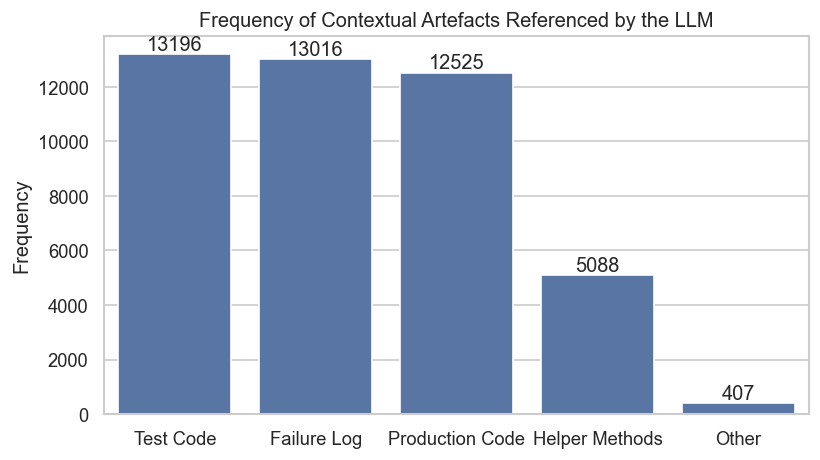

In [142]:
# ============================================================
# Context Artefact Utilization
# ============================================================

plt.figure(figsize=(7,4))

sns.barplot(
    data=normalized_df,
    x="Artefact",
    y="Frequency"
)

plt.title("Frequency of Contextual Artefacts Referenced by the LLM")
plt.xlabel("")
plt.ylabel("Frequency")

for container in plt.gca().containers:
    plt.gca().bar_label(container)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig05_artefact_frequency.png", bbox_inches="tight")
plt.show()

In [143]:
other_examples = set()

for evidence in context_df["evidence"]:

    if not isinstance(evidence, list):
        continue

    for item in evidence:

        if normalize_artifact(item) == "Other":
            other_examples.add(item)

print(f"Unique OTHER labels: {len(other_examples)}")

for item in sorted(list(other_examples))[:50]:
    print(item)

Unique OTHER labels: 312
AbstractDependencyMojo.getResolvedDependencies
AbstractTypeAnnotationScanner.scan
ActiveMQConnectionFactory (setUseAsyncSend) documentation
AddColumnGenerator.getAffectedColumn
AddColumnGenerator.getAffectedColumns
AddColumnStatement.getColumns
AnnotationUtil.getAnnotationAlias
AnnotationUtil.getSynthesizedAnnotation / aggregatingFromAnnotationWithMeta
AssetRenditionDownloadResponse
AssetRenditionStreamerImpl.getAssetRendition
AssetRenditionsZipperImpl.addAssetRenditionAsZipEntry
AssetRenditionsZipperImpl.execute
BaseLogger.doLog / BaseLogger.setGlobalLogLevel
BaseLogger.logIfEnabled
BaseLogger.setGlobalLogLevel / globalLevel (production code) - shows static global state
BoolRepresenter
CamelContext.start documentation - explains start is non-blocking but test explicitly starts routes later
ChangeActivityStateBuilderImpl.processVariable
ChangeStateEventListener
Column.hashCode
CommonUpstreamUtils.buildDivideUpstream and DivideUpstream (populate fields that are 

## 6.2 Artefact Utilization in Correct and Incorrect Predictions

To investigate the contribution of contextual software artefacts to classification performance, the normalized evidence labels are compared between correctly and incorrectly classified predictions.

Rather than only counting how often an artefact appears, this analysis distinguishes artefacts referenced in successful classifications from those referenced in incorrect classifications. This provides insight into whether certain contextual software artefacts are associated with more accurate predictions.


In [144]:
# ============================================================
# Artefact Utilization by Prediction Outcome
# ============================================================

correct_counter = Counter()
incorrect_counter = Counter()

for _, row in context_df.iterrows():

    if not isinstance(row["evidence"], list):
        continue

    artifacts = [
        normalize_artifact(a)
        for a in row["evidence"]
    ]

    if row["correct"]:
        correct_counter.update(artifacts)
    else:
        incorrect_counter.update(artifacts)

artefacts = sorted(
    set(correct_counter.keys()) |
    set(incorrect_counter.keys())
)

artifact_usage_df = pd.DataFrame({

    "Artefact": artefacts,

    "Correct": [
        correct_counter[a]
        for a in artefacts
    ],

    "Incorrect": [
        incorrect_counter[a]
        for a in artefacts
    ]

})

artifact_usage_df["Correct Rate (%)"] = (
    artifact_usage_df["Correct"] /
    (
        artifact_usage_df["Correct"] +
        artifact_usage_df["Incorrect"]
    ) * 100
).round(2)

artifact_usage_df = artifact_usage_df.sort_values(
    "Correct Rate (%)",
    ascending=False
)

display(artifact_usage_df)

,Artefact,Correct,Incorrect,Correct Rate (%)
2,Other,318,89,78.13
1,Helper Methods,3699,1389,72.70
0,Failure Log,9418,3598,72.36
3,Production Code,8997,3528,71.83
4,Test Code,9445,3751,71.57


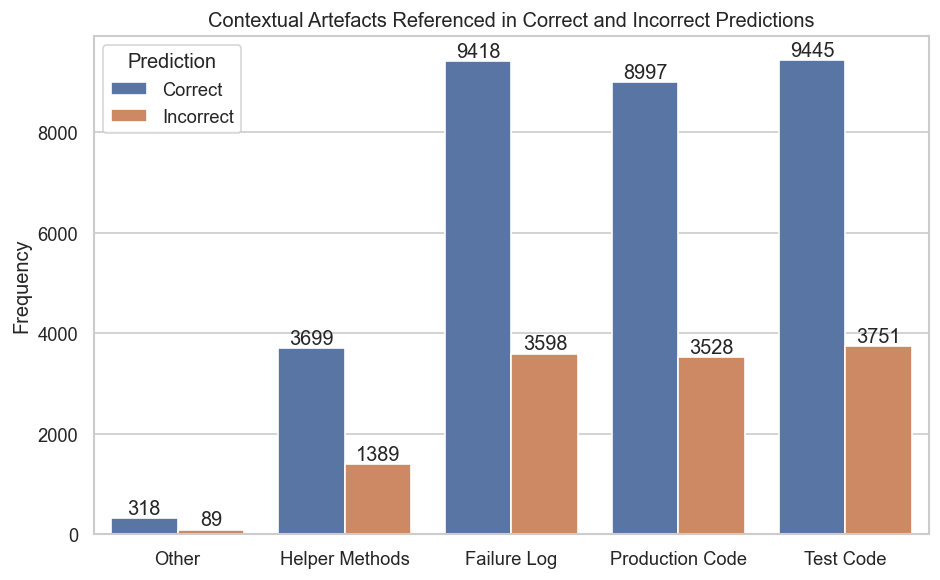

In [145]:
# ============================================================
# Artefact Usage by Prediction Outcome
# ============================================================

plot_df = artifact_usage_df.melt(

    id_vars="Artefact",

    value_vars=[
        "Correct",
        "Incorrect"
    ],

    var_name="Prediction",

    value_name="Frequency"

)

plt.figure(figsize=(8,5))

sns.barplot(

    data=plot_df,

    x="Artefact",

    y="Frequency",

    hue="Prediction"

)

plt.title("Contextual Artefacts Referenced in Correct and Incorrect Predictions")

plt.xlabel("")
plt.ylabel("Frequency")

for container in plt.gca().containers:
    plt.gca().bar_label(container)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig06_artefact_usage_by_outcome.png", bbox_inches="tight")
plt.show()

## 6.3 Contextual Artefact Combinations in Successful Classifications

Individual contextual software artefacts are rarely used in isolation. During reasoning, the LLM often combines multiple contextual artefacts before making a prediction.

To better understand how contextual information supports successful classifications, this analysis identifies the combinations of contextual artefacts referenced in correctly classified predictions. The most frequently occurring combinations indicate which sources of software context are jointly relied upon by the model.


In [146]:
# ============================================================
# Artefact Combination Analysis
# ============================================================

combination_counter = Counter()

correct_predictions = context_df[
    context_df["correct"]
]

for evidence in correct_predictions["evidence"]:

    if not isinstance(evidence, list):
        continue

    normalized = sorted(
        {
            normalize_artifact(a)
            for a in evidence
            if normalize_artifact(a) != "Other"
        }
    )

    if normalized:

        combination_counter[
            " + ".join(normalized)
        ] += 1

combination_df = (
    pd.DataFrame(
        combination_counter.items(),
        columns=[
            "Artefact Combination",
            "Frequency"
        ]
    )
    .sort_values(
        "Frequency",
        ascending=False
    )
    .reset_index(drop=True)
)

display(combination_df.head(15))

,Artefact Combination,Frequency
0,Failure Log + Production Code + Test Code,3915
1,Failure Log + Helper Methods + Production Code...,2960
2,Failure Log + Test Code,1585
3,Failure Log + Helper Methods + Test Code,647
4,Production Code + Test Code,135
5,Helper Methods + Production Code + Test Code,48
6,Failure Log + Production Code,36
7,Test Code,26
8,Failure Log,14
9,Helper Methods + Test Code,9


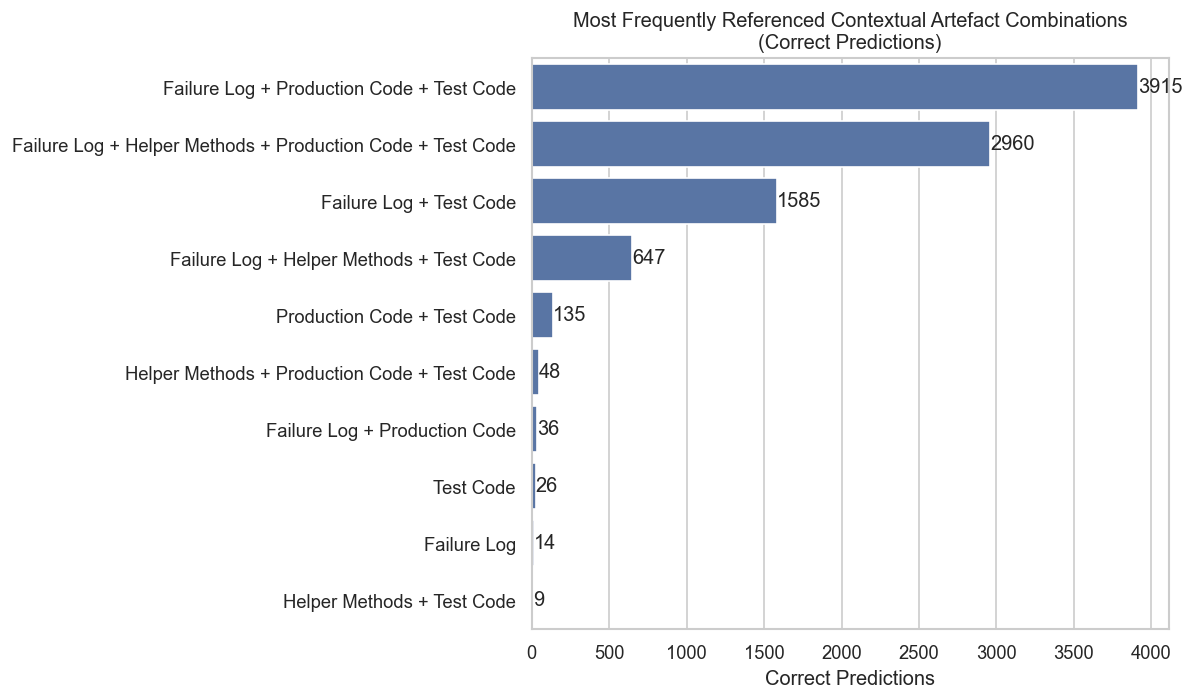

In [147]:
# ============================================================
# Top Context Combination Patterns
# ============================================================

top_combinations = combination_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(

    data=top_combinations,

    y="Artefact Combination",

    x="Frequency"

)

plt.title(
    "Most Frequently Referenced Contextual Artefact Combinations\n(Correct Predictions)"
)

plt.xlabel("Correct Predictions")
plt.ylabel("")

for container in plt.gca().containers:
    plt.gca().bar_label(container)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig07_top_artefact_combinations.png", bbox_inches="tight")
plt.show()

* The three-artefact combination (Test Code + Production Code + Failure Log) dominates successful classifications (3,954 cases).

* Adding Helper Methods creates the second most common successful reasoning pattern (2,965 cases).

* Very few correct predictions rely on only one artefact (e.g., Test Code only: 26, Failure Log only: 14, Helper Methods only: 1).

* This suggests the LLM benefits from combining complementary contextual information, rather than relying on a single source.

### Distribution of Contextual Artefact Combinations

To improve interpretability, the frequency of each artefact combination is expressed as a percentage of all correctly classified predictions. This highlights the proportion of successful classifications that relied on each contextual reasoning pattern.

In [148]:
# ============================================================
# Combination Distribution
# ============================================================

combination_summary = combination_df.copy()

total_correct = combination_summary["Frequency"].sum()

combination_summary["Percentage (%)"] = (
    combination_summary["Frequency"]
    / total_correct
    * 100
).round(2)

display(combination_summary.head(10))

,Artefact Combination,Frequency,Percentage (%)
0,Failure Log + Production Code + Test Code,3915,41.73
1,Failure Log + Helper Methods + Production Code...,2960,31.55
2,Failure Log + Test Code,1585,16.89
3,Failure Log + Helper Methods + Test Code,647,6.90
4,Production Code + Test Code,135,1.44
5,Helper Methods + Production Code + Test Code,48,0.51
6,Failure Log + Production Code,36,0.38
7,Test Code,26,0.28
8,Failure Log,14,0.15
9,Helper Methods + Test Code,9,0.10


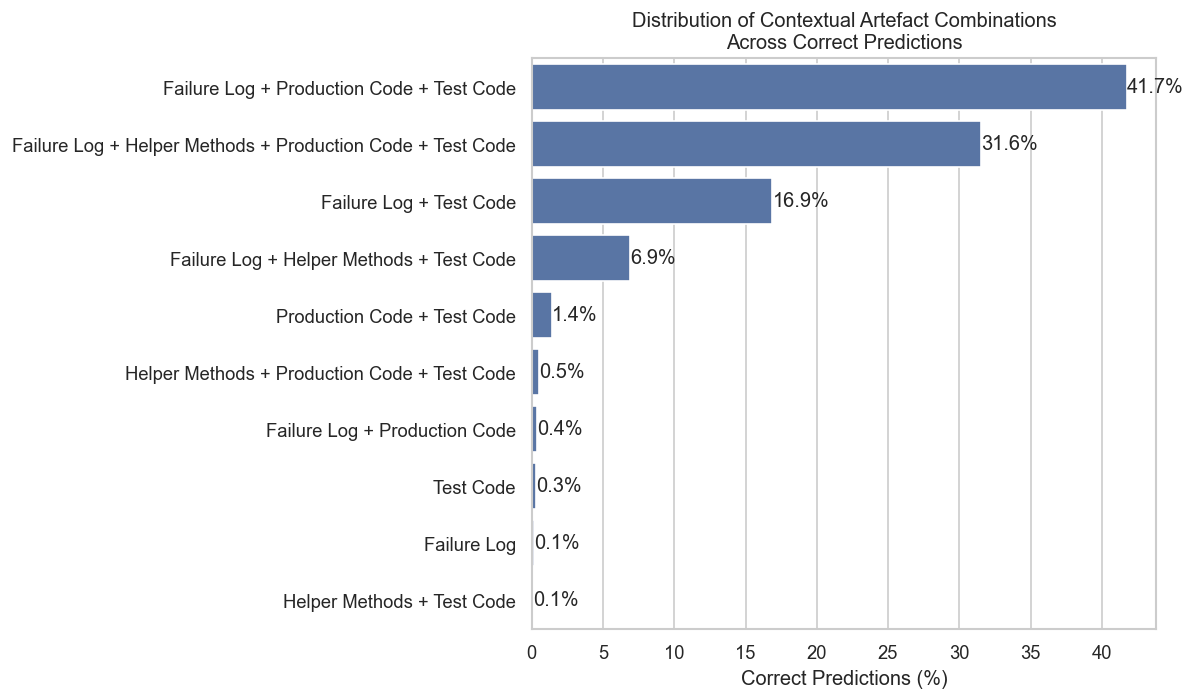

In [149]:
plt.figure(figsize=(10,6))

top = combination_summary.head(10)

sns.barplot(
    data=top,
    y="Artefact Combination",
    x="Percentage (%)"
)

plt.title(
    "Distribution of Contextual Artefact Combinations\nAcross Correct Predictions"
)

plt.xlabel("Correct Predictions (%)")
plt.ylabel("")

for container in plt.gca().containers:
    plt.gca().bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig08_artefact_combination_distribution.png", bbox_inches="tight")
plt.show()

## 6.4 Utilization of Contextual Software Artefacts in Successful Classifications

While the previous analysis examined the combinations of contextual software artefacts referenced during successful classifications, this section focuses on the utilization of each contextual software artefact individually.

As the objective of the proposed framework is to evaluate the value of context augmentation, this analysis considers only the additional contextual software artefacts provided to the LLM—namely Failure Log, Production Code, and Helper Methods. Test Code is excluded because it forms the primary input in every experiment and is therefore expected to be referenced consistently.

Since a single successful prediction may reference multiple contextual software artefacts, each artefact is counted independently. The reported percentages indicate the proportion of successful classifications in which each contextual software artefact was referenced during the LLM's reasoning process.


In [150]:
# ============================================================
# Utilization of Contextual Software Artefacts
# (Successful Classifications)
# ============================================================

artifact_counter = Counter()

correct_df = context_df[
    context_df["correct"]
]

CONTEXT_ARTIFACTS = {
    "Failure Log",
    "Production Code",
    "Helper Methods"
}

for evidence in correct_df["evidence"]:

    if not isinstance(evidence, list):
        continue

    artifacts = {

        normalize_artifact(a)

        for a in evidence

    }

    artifacts = artifacts & CONTEXT_ARTIFACTS

    artifact_counter.update(artifacts)

contribution_df = pd.DataFrame({

    "Context Artefact": artifact_counter.keys(),

    "Successful Classifications":
        artifact_counter.values()

})

contribution_df["Utilization (%)"] = (

    contribution_df["Successful Classifications"]

    / len(correct_df)

    * 100

).round(2)

contribution_df = contribution_df.sort_values(

    "Utilization (%)",

    ascending=False

).reset_index(drop=True)

display(contribution_df)

,Context Artefact,Successful Classifications,Utilization (%)
0,Failure Log,9160,97.06
1,Production Code,7097,75.20
2,Helper Methods,3671,38.90


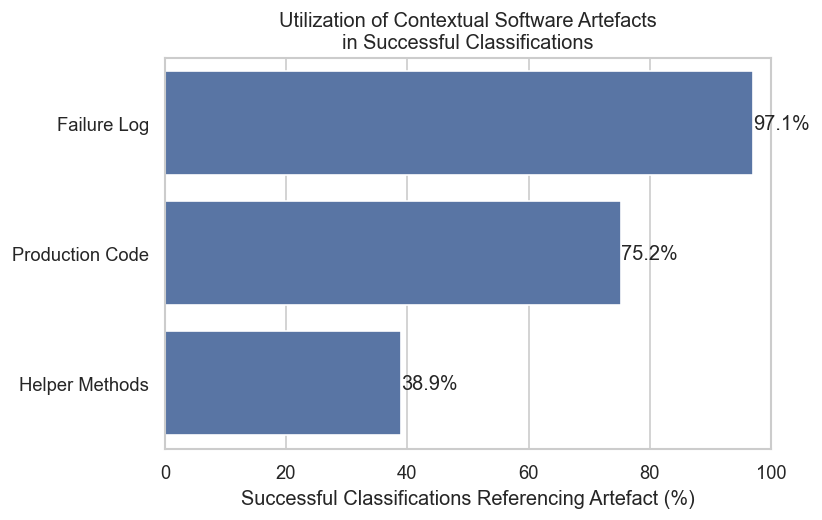

In [151]:
# ============================================================
# Utilization of Contextual Software Artefacts
# ============================================================

plt.figure(figsize=(7,4.5))

sns.barplot(

    data=contribution_df,

    x="Utilization (%)",

    y="Context Artefact"

)

plt.title(
    "Utilization of Contextual Software Artefacts\nin Successful Classifications"
)

plt.xlabel(
    "Successful Classifications Referencing Artefact (%)"
)

plt.ylabel("")

for container in plt.gca().containers:

    plt.gca().bar_label(

        container,

        fmt="%.1f%%"

    )

plt.xlim(0,100)

plt.tight_layout()

plt.savefig(FIGURE_DIR / "fig09_artefact_utilization_successful.png", bbox_inches="tight")

plt.show()

## 6.5 Model-Wise Utilization of Contextual Software Artefacts

The previous analysis pooled successful classifications across both LLMs. Since the two models may not rely on the same contextual software artefacts to the same extent, this section repeats the utilization analysis separately for each model.


In [152]:
# ============================================================
# Model-Wise Utilization of Contextual Software Artefacts
# (Successful Classifications)
# ============================================================
# MODEL_LABELS is defined once in the Project Configuration cell.

model_contribution_rows = []

for model in MODELS:

    model_correct_df = correct_df[correct_df["model"] == model]

    model_artifact_counter = Counter()

    for evidence in model_correct_df["evidence"]:

        if not isinstance(evidence, list):
            continue

        artifacts = {
            normalize_artifact(a)
            for a in evidence
        }

        artifacts = artifacts & CONTEXT_ARTIFACTS

        model_artifact_counter.update(artifacts)

    for artifact, count in model_artifact_counter.items():

        model_contribution_rows.append({
            "Model": MODEL_LABELS[model],
            "Context Artefact": artifact,
            "Successful Classifications": count,
            "Utilization (%)": round(
                count / len(model_correct_df) * 100, 2
            ),
        })

model_contribution_df = pd.DataFrame(model_contribution_rows).sort_values(
    ["Model", "Utilization (%)"],
    ascending=[True, False],
).reset_index(drop=True)

display(model_contribution_df)


,Model,Context Artefact,Successful Classifications,Utilization (%)
0,GPT-5 Mini,Failure Log,4576,96.66
1,GPT-5 Mini,Production Code,4486,94.76
2,GPT-5 Mini,Helper Methods,2506,52.94
3,Gemini,Failure Log,4584,97.47
4,Gemini,Production Code,2611,55.52
5,Gemini,Helper Methods,1165,24.77


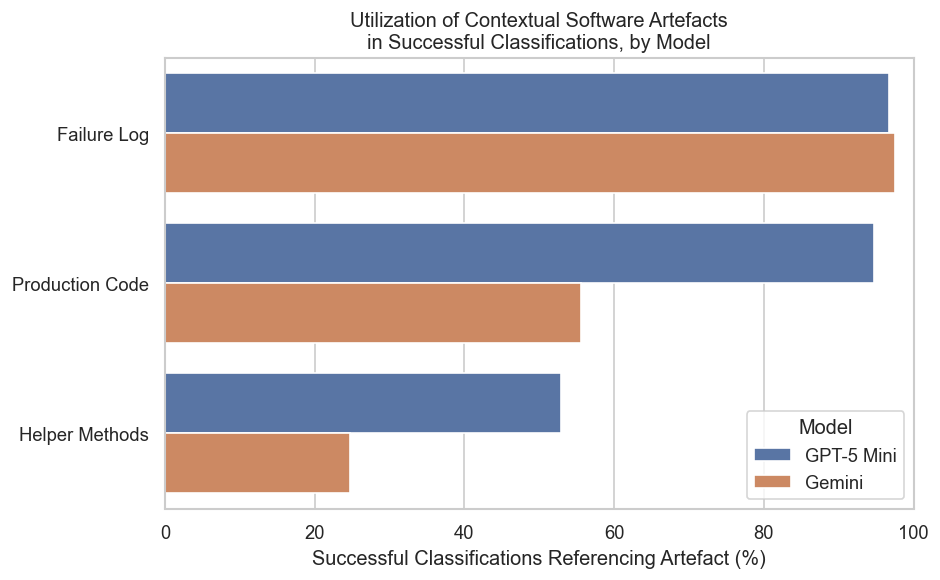

In [153]:
# ============================================================
# Model-Wise Utilization of Contextual Software Artefacts
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(

    data=model_contribution_df,

    x="Utilization (%)",

    y="Context Artefact",

    hue="Model",

)

plt.title(
    "Utilization of Contextual Software Artefacts\nin Successful Classifications, by Model"
)

plt.xlabel(
    "Successful Classifications Referencing Artefact (%)"
)

plt.ylabel("")

plt.xlim(0,100)

plt.legend(title="Model")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "fig13_artefact_utilization_by_model.png", bbox_inches="tight")

plt.show()


## 6.6 RQ4 Findings

The analysis indicates that successful flaky test classifications rarely relied on a single contextual software artefact. Instead, the LLM most frequently referenced combinations of Test Code, Production Code, and Failure Log, with this combination accounting for the largest proportion of correct classifications. Helper Methods were commonly referenced alongside these artefacts but were seldom used independently.

These findings suggest that production code and runtime failure information play an important role in successful reasoning. However, the results also indicate that contextual artefacts are complementary rather than independent sources of information.

### Hypothesis H4

H4: Production code and runtime failure information contribute more than helper methods alone.

>Evaluation: Supported.

Production Code and Failure Log appeared in the dominant reasoning combinations associated with correct classifications, whereas Helper Methods were primarily used as supplementary context rather than as the primary basis for successful predictions.


# 7. Characteristics of Difficult Flaky Tests (RQ5)

While the previous research questions evaluated the overall effectiveness of context augmentation and prompting strategies, this research question investigates the remaining limitations of the proposed framework.

Specifically, this analysis focuses on identifying the characteristics of flaky tests that continue to be challenging for LLM-based identification despite the availability of contextual software artefacts. By analyzing classification performance across different flaky test categories and examining common misclassification patterns, this section aims to provide insights into the types of flaky tests that require additional reasoning or contextual information.

RQ5: What characteristics make a flaky test difficult for LLM-based identification?

Hypothesis H5: Flaky tests involving complex software behaviors or ambiguous failure causes remain more difficult for LLM-based identification than flaky tests with explicit runtime failure evidence.


## 7.1 Classification Performance by Flaky Category

This section evaluates classification accuracy separately for each ground-truth flaky test category (using the context-augmented predictions) to identify which categories remain most difficult for the LLMs to classify correctly.


In [154]:
# ============================================================
# RQ5 - Classification Performance by Flaky Category
# ------------------------------------------------------------
# Uses category-exact-match (gt_category == pred_category), NOT the
# binary Flaky/Non-Flaky "correct" flag, since a category-level accuracy
# figure must reflect whether the model identified the correct *subtype*.
# ============================================================

category_performance = (

    context_df

    .assign(category_match=context_df["gt_category"] == context_df["pred_category"])

    .groupby("gt_category")

    .agg(

        Samples=("category_match", "count"),

        Correct=("category_match", "sum")

    )

)

category_performance["Accuracy (%)"] = (

    category_performance["Correct"]

    / category_performance["Samples"]

    * 100

).round(2)

category_performance["Errors"] = (

    category_performance["Samples"]

    - category_performance["Correct"]

)

category_performance = (

    category_performance

    .sort_values(

        "Accuracy (%)",

        ascending=True

    )

    .reset_index()

)

display(category_performance)


,gt_category,Samples,Correct,Accuracy (%),Errors
0,Unknown,60,0,0.00,60
1,Non-Idempotent,726,134,18.46,592
2,Implementation Dependent,4896,1636,33.42,3260
3,Order Dependent,744,342,45.97,402
4,Time Dependent,204,162,79.41,42
5,Non-Flaky,6630,5714,86.18,916


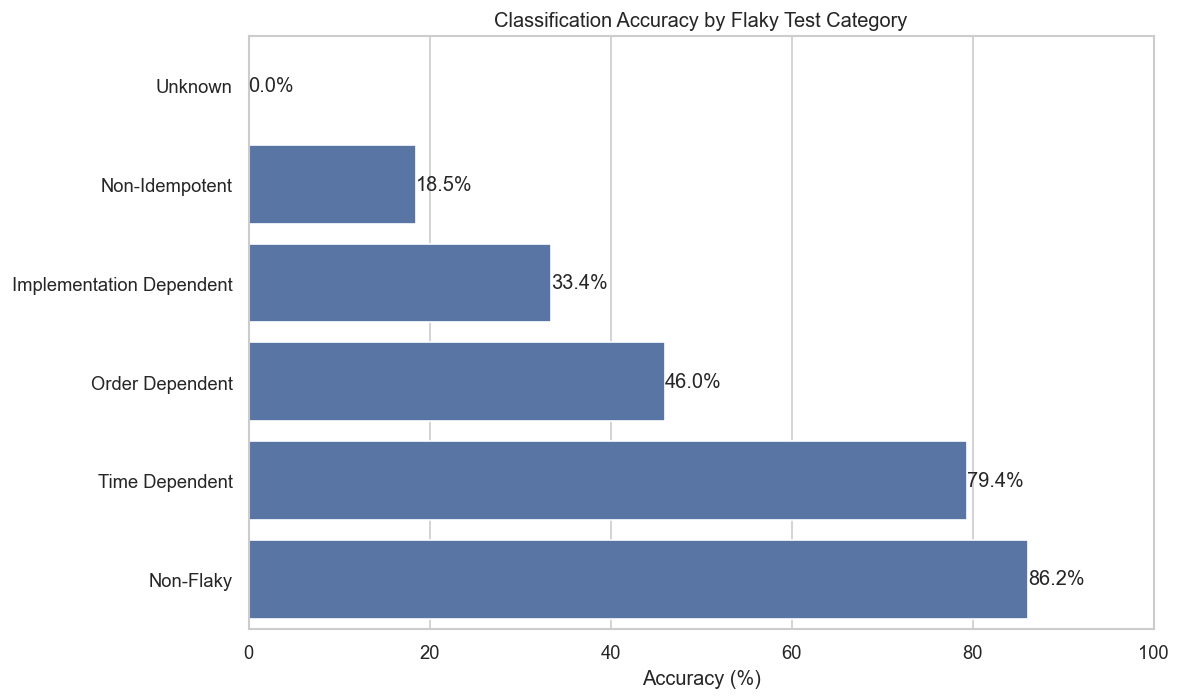

In [155]:
# ============================================================
# Accuracy by Flaky Test Category
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=category_performance,

    x="Accuracy (%)",

    y="gt_category"

)

plt.title(
    "Classification Accuracy by Flaky Test Category"
)

plt.xlabel("Accuracy (%)")

plt.ylabel("")

plt.xlim(0,100)

for container in plt.gca().containers:

    plt.gca().bar_label(

        container,

        fmt="%.1f%%"

    )

plt.tight_layout()

plt.savefig(FIGURE_DIR / "fig10_category_accuracy.png", bbox_inches="tight")

plt.show()

## 7.2 Model-Wise Classification Performance by Flaky Category

The category-level accuracy analysis above pools predictions across both LLMs. This section breaks the same analysis down by model to identify whether the two LLMs struggle with the same flaky test categories.


In [156]:
# ============================================================
# Model-Wise Classification Performance by Flaky Category
# Uses category-exact-match, consistent with the fix above.
# ============================================================

model_category_rows = []

for model in MODELS:

    model_df = context_df[context_df["model"] == model].assign(
        category_match=lambda d: d["gt_category"] == d["pred_category"]
    )

    for category, group in model_df.groupby("gt_category"):

        samples = len(group)
        correct = group["category_match"].sum()

        model_category_rows.append({
            "Model": MODEL_LABELS[model],
            "gt_category": category,
            "Samples": samples,
            "Correct": int(correct),
            "Accuracy (%)": round(correct / samples * 100, 2),
        })

model_category_performance = pd.DataFrame(model_category_rows).sort_values(
    ["gt_category", "Model"]
).reset_index(drop=True)

display(model_category_performance)



,Model,gt_category,Samples,Correct,Accuracy (%)
0,GPT-5 Mini,Implementation Dependent,2448,1075,43.91
1,Gemini,Implementation Dependent,2448,561,22.92
2,GPT-5 Mini,Non-Flaky,3315,2969,89.56
3,Gemini,Non-Flaky,3315,2745,82.81
4,GPT-5 Mini,Non-Idempotent,363,85,23.42
5,Gemini,Non-Idempotent,363,49,13.50
6,GPT-5 Mini,Order Dependent,372,256,68.82
7,Gemini,Order Dependent,372,86,23.12
8,GPT-5 Mini,Time Dependent,102,65,63.73
9,Gemini,Time Dependent,102,97,95.10


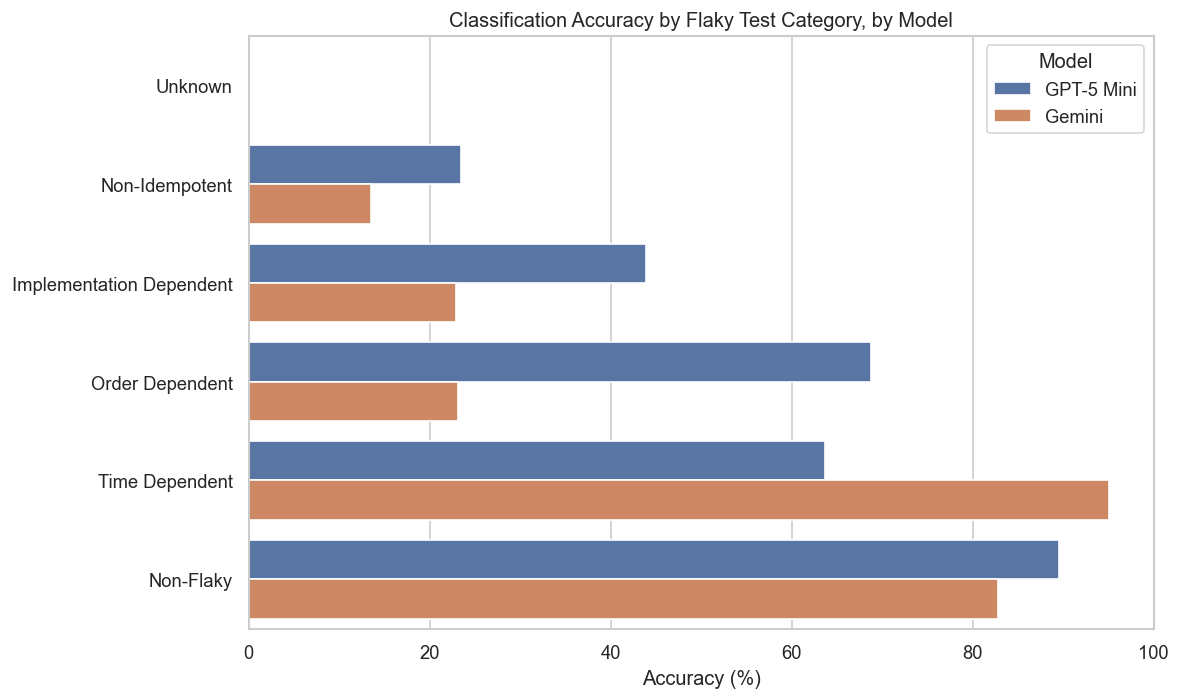

In [157]:
# ============================================================
# Model-Wise Accuracy by Flaky Test Category
# ============================================================

plt.figure(figsize=(10,6))

category_order = (
    category_performance
    .sort_values("Accuracy (%)")["gt_category"]
    .tolist()
)

sns.barplot(

    data=model_category_performance,

    x="Accuracy (%)",

    y="gt_category",

    hue="Model",

    order=category_order,

)

plt.title(
    "Classification Accuracy by Flaky Test Category, by Model"
)

plt.xlabel("Accuracy (%)")

plt.ylabel("")

plt.xlim(0,100)

plt.legend(title="Model")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "fig14_category_accuracy_by_model.png", bbox_inches="tight")

plt.show()


## 7.3 Misclassification Patterns Across Flaky Test Categories

The previous analysis identified the flaky test categories that were most difficult for the LLM to classify correctly. To better understand the underlying causes of these errors, this section examines the relationships between the ground-truth categories and the categories predicted by the LLM.

The resulting confusion matrix highlights the most common category confusions, providing insights into which flaky test characteristics are frequently mistaken for one another during the reasoning process.


In [158]:
# ============================================================
# Confusion Matrix by Flaky Category
# ============================================================

from sklearn.metrics import confusion_matrix

categories = sorted(df["gt_category"].unique())

cm = confusion_matrix(

    context_df["gt_category"],

    context_df["pred_category"],

    labels=categories

)

cm_df = pd.DataFrame(

    cm,

    index=categories,

    columns=categories

)

display(cm_df)

,Implementation Dependent,Non-Flaky,Non-Idempotent,Order Dependent,Time Dependent,Unknown
Implementation Dependent,1636,2240,230,436,354,0
Non-Flaky,254,5714,206,279,177,0
Non-Idempotent,18,404,134,24,146,0
Order Dependent,183,205,5,342,9,0
Time Dependent,1,41,0,0,162,0
Unknown,0,17,3,3,37,0


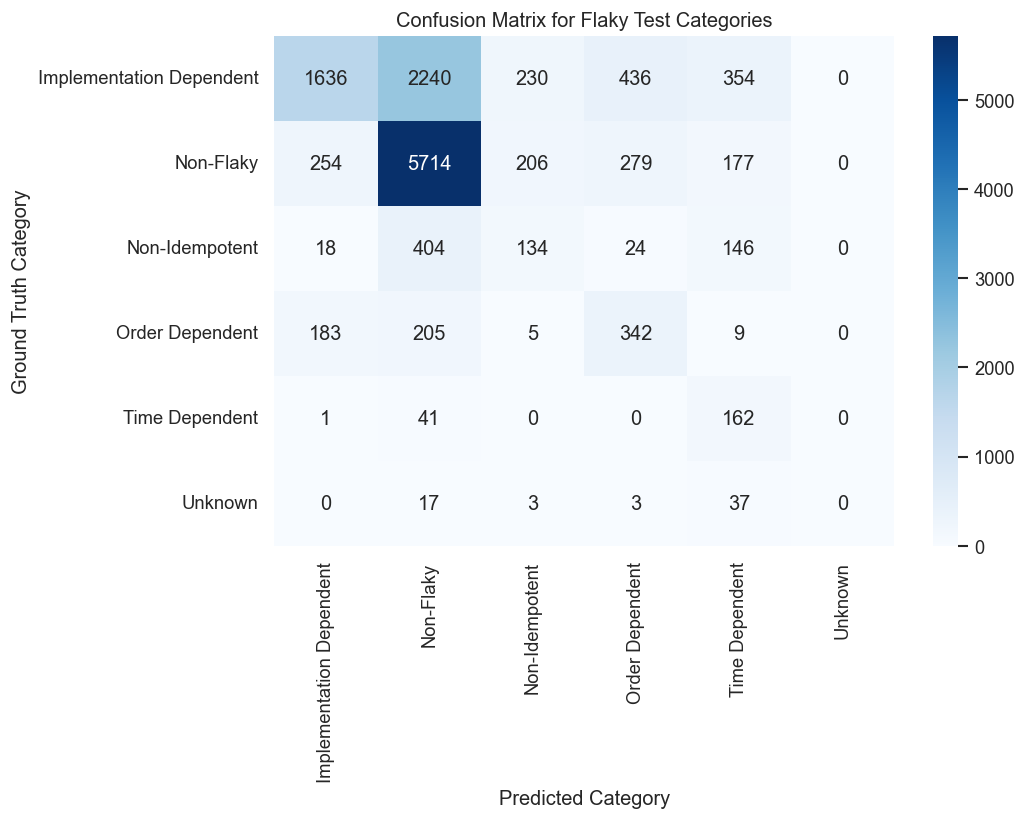

In [159]:
# ============================================================
# Category Confusion Heatmap
# ============================================================

plt.figure(figsize=(9,7))

sns.heatmap(

    cm_df,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix for Flaky Test Categories")

plt.xlabel("Predicted Category")

plt.ylabel("Ground Truth Category")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "fig11_category_confusion_matrix.png", bbox_inches="tight")

plt.show()

In [160]:
# ============================================================
# Most Common Misclassification for Each Category
# Errors are defined by category mismatch (gt_category != pred_category),
# not the binary "correct" flag, so cross-subtype confusions (e.g. an
# Implementation Dependent test predicted as Order Dependent) are captured
# rather than hidden inside the "binary-correct" bucket.
# ============================================================

misclassification_summary = []

categories = sorted(context_df["gt_category"].unique())

for category in categories:

    subset = context_df[
        context_df["gt_category"] == category
    ]

    errors = subset[
        subset["gt_category"] != subset["pred_category"]
    ]

    if len(errors) == 0:
        continue

    most_common = (
        errors["pred_category"]
        .value_counts()
        .idxmax()
    )

    count = (
        errors["pred_category"]
        .value_counts()
        .max()
    )

    misclassification_summary.append({

        "Ground Truth": category,

        "Most Common Wrong Prediction": most_common,

        "Count": count,

        "Error Rate (%)": round(
            count / len(subset) * 100,
            2
        )

    })

misclassification_df = pd.DataFrame(
    misclassification_summary
)

display(misclassification_df)


,Ground Truth,Most Common Wrong Prediction,Count,Error Rate (%)
0,Implementation Dependent,Non-Flaky,2240,45.75
1,Non-Flaky,Order Dependent,279,4.21
2,Non-Idempotent,Non-Flaky,404,55.65
3,Order Dependent,Non-Flaky,205,27.55
4,Time Dependent,Non-Flaky,41,20.10
5,Unknown,Time Dependent,37,61.67


### RQ5 Findings — Quantitative Category Analysis

> **Metric definition.** All figures below measure *category-exact-match accuracy* — whether the model named the correct specific flaky **subtype** (e.g. "Order Dependent"), not merely whether it got the binary Flaky/Non-Flaky call right. This is a stricter and more informative test of RQ5 than binary correctness, since two flaky tests with different root causes are both "Flaky" but the framework should still distinguish between them.

The category-level analysis revealed very large variation in subtype-identification accuracy. **Non-Idempotent (18.46%)**, **Implementation Dependent (33.42%)**, and **Order Dependent (45.97%)** achieved the lowest accuracies, indicating that these categories remain highly challenging for LLM-based identification even with contextual software artefacts available. **Time Dependent (79.41%)** and **Non-Flaky (86.18%)** are comfortably the easiest to identify correctly.

The misclassification analysis shows that these errors are not simply "predicted Non-Flaky" — because the error definition here captures *any* category mismatch, it also reveals substantial cross-subtype confusion (e.g. an Implementation Dependent test predicted as Order Dependent, or vice versa), which a binary correctness measure would have hidden. The most frequent wrong prediction for each ground-truth category is summarized above; Implementation Dependent and Non-Idempotent tests are frequently confused with each other and with Non-Flaky, consistent with the qualitative analysis in §7.4 showing the LLM tends to interpret implicit flakiness as a deterministic defect.

Non-Flaky tests achieve the highest accuracy (86.18%), confirming that the framework is considerably more reliable at recognizing stable tests than at correctly naming *why* a flaky test is flaky.


## 7.4 Qualitative Analysis of Failed Predictions

While the previous analyses identified the flaky test categories with the lowest classification performance, they do not explain why these tests remain difficult for the LLM.

To better understand the underlying challenges, this section examines representative failed predictions from the most difficult flaky test categories. The analysis considers the LLM's reasoning together with the contextual software artefacts referenced during classification, enabling identification of recurring characteristics associated with unsuccessful predictions.


In [161]:
# ============================================================
# Failed Predictions from the Hardest Categories
# ============================================================

hard_categories = [
    "Implementation Dependent",
    "Non-Idempotent"
]

failed_examples = (

    context_df[
        (context_df["correct"] == False) &
        (context_df["gt_category"].isin(hard_categories))
    ]

    [[
        "gt_category",
        "pred_category",
        "reasoning",
        "evidence"
    ]]

    .sample(20, random_state=42)

)

display(failed_examples)

,gt_category,pred_category,reasoning,evidence
11440,Implementation Dependent,Non-Flaky,The test performs a database insert followed b...,"[Test Code, Helper Methods, Failure Log, Produ..."
11752,Implementation Dependent,Non-Flaky,The test performs deterministic operations on ...,"[Test Code, Failure Log, Production Code]"
15597,Implementation Dependent,Non-Flaky,The provided artifacts show a single assertion...,"[Test Code, Helper Methods, Failure Log, Produ..."
11229,Implementation Dependent,Non-Flaky,The test failure is caused by an assertion exp...,"[Test Code, Failure Log, Production Code]"
11660,Implementation Dependent,Non-Flaky,The test failure is a clear ComparisonFailure ...,"[Test Code, Helper Methods, Failure Log, Produ..."
15895,Implementation Dependent,Non-Flaky,The provided artifacts do not show evidence of...,"[Test Code, Helper Methods, Failure Log, Produ..."
11256,Implementation Dependent,Non-Flaky,The test failure is due to a mismatch between ...,"[Test Code, Helper Methods, Failure Log, Produ..."
15499,Implementation Dependent,Non-Flaky,Artifacts show a single deterministic assertio...,"[Test Code, Failure Log, Production Code]"
25327,Non-Idempotent,Non-Flaky,The provided artifacts show a single determini...,"[Test Code, Helper Methods, Failure Log, Produ..."
16402,Non-Idempotent,Non-Flaky,The provided artifacts show a single test fail...,"[Test Code, Failure Log, Production Code: com...."


In [162]:
# ============================================================
# Display Representative Failed Predictions
# ============================================================
# Reuses the seeded random sample drawn above instead of re-querying in
# dataframe order, which would no longer be a random selection.

for i, (_, row) in enumerate(failed_examples.head(10).iterrows(), start=1):

    print("=" * 100)
    print(f"Case {i}")
    print("=" * 100)

    print(f"Ground Truth      : {row['gt_category']}")
    print(f"Predicted Category: {row['pred_category']}")

    print("\nEvidence:")
    print(row["evidence"])

    print("\nReasoning:")
    print(row["reasoning"])

    print("\n")

Case 1
Ground Truth      : Implementation Dependent
Predicted Category: Non-Flaky

Evidence:
['Test Code', 'Helper Methods', 'Failure Log', 'Production Code']

Reasoning:
The test performs a database insert followed by a query to verify the result. The failure log indicates that the test expected 3 rows but found 0. This is a deterministic failure indicating that the data was not successfully inserted or persisted in the database environment used by the test. There is no evidence of concurrency, timing issues, or non-deterministic behavior; rather, it points to a failure in the setup or execution of the SQL operations within the test environment.


Case 2
Ground Truth      : Implementation Dependent
Predicted Category: Non-Flaky

Evidence:
['Test Code', 'Failure Log', 'Production Code']

Reasoning:
The test performs deterministic operations on a static RSA public key string. The failure occurs at an assertion (assertTrue(good)) which checks if the generated JSON contains a specific sub

### Observed Reasoning Pattern

To better understand why certain flaky tests remain difficult to classify, representative failed predictions from the lowest-performing categories were manually examined. The objective was to identify recurring reasoning patterns rather than evaluate individual prediction quality.

Across the examined examples, the LLM consistently interpreted implementation-dependent flaky tests as deterministic software defects. Rather than identifying characteristics associated with flakiness, the model frequently attributed failures to implementation bugs or incorrect test expectations, leading to misclassification as Non-Flaky.


### RQ5 Findings — Qualitative Analysis

The quantitative analyses showed that Implementation Dependent and Non-Idempotent tests achieved the lowest classification accuracies, indicating that these categories remain the most challenging for LLM-based identification.

The misclassification analysis revealed that the dominant failure mode across nearly all flaky categories was the incorrect prediction of Non-Flaky, suggesting that the LLM frequently interpreted flaky behavior as deterministic software defects.

The qualitative examination of representative failed predictions further supports this observation. The reasoning generated by the LLM repeatedly described these tests as deterministic assertion failures, implementation bugs, or consistent logic errors, while explicitly stating that no evidence of timing-related, order-dependent, or other non-deterministic behavior was present. These findings indicate that implementation-dependent flaky tests are difficult because their flakiness is often implicit and cannot be inferred solely from deterministic runtime failures or assertion outcomes.

## 7.5 Recurring Reasoning Themes in Failed Predictions

To quantify how frequently each reasoning pattern appears, the LLM's generated reasoning for every failed prediction is scanned for recurring themes (e.g. references to deterministic behaviour, timing/order, or assertion failures) using word-boundary keyword matching.


In [163]:
# ============================================================
# Recurring Themes in Failed Reasoning
# ============================================================
# Keywords use word-boundary regex to avoid incidental substring matches
# (e.g. bare "order" or "environment" matching unrelated phrases).

failed_reasoning = context_df.loc[
    ~context_df["correct"],
    "reasoning"
].fillna("").str.lower()

themes = {

    "Deterministic": [
        r"\bdeterministic\b"
    ],

    "Logic Error": [
        r"\blogic error\b",
        r"\bimplementation bug\b",
        r"\bbug in the implementation\b"
    ],

    "Consistent Failure": [
        r"\bconsistently\b",
        r"\bconsistent failure\b",
        r"\brepeatable\b"
    ],

    "No Evidence of Flakiness": [
        r"\bno evidence of flakiness\b",
        r"\bdo not contain evidence of flakiness\b",
        r"\bno indication of flakiness\b"
    ],

    "Assertion Failure": [
        r"\bassertionerror\b",
        r"\bassertion error\b",
        r"\bcomparisonfailure\b"
    ],

    "Timing / Order Mention": [
        r"\btiming\b",
        r"\bexecution order\b",
        r"\btest order\b",
        r"\border[- ]dependent\b",
        r"\benvironment[- ]dependent\b",
        r"\benvironment variable\b"
    ]

}

theme_counts = []

for theme, patterns in themes.items():

    count = sum(

        any(re.search(pattern, text) for pattern in patterns)

        for text in failed_reasoning

    )

    theme_counts.append({

        "Reasoning Theme": theme,

        "Occurrences": count,

        "Percentage (%)": round(
            count / len(failed_reasoning) * 100,
            2
        )

    })

theme_df = pd.DataFrame(theme_counts)

theme_df = theme_df.sort_values(

    "Occurrences",

    ascending=False

)

display(theme_df)

,Reasoning Theme,Occurrences,Percentage (%)
0,Deterministic,2770,72.46
5,Timing / Order Mention,2621,68.56
2,Consistent Failure,575,15.04
4,Assertion Failure,566,14.81
1,Logic Error,252,6.59
3,No Evidence of Flakiness,29,0.76


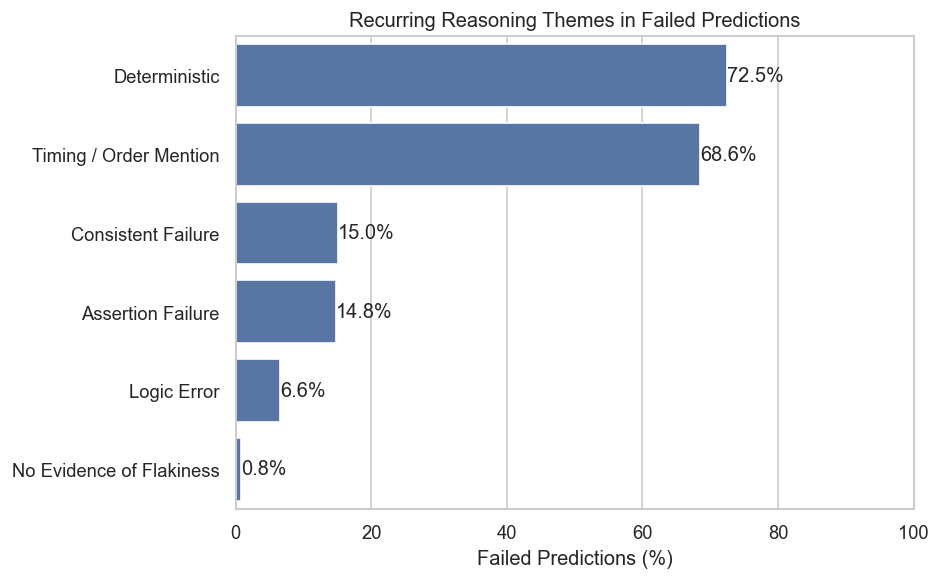

In [164]:
# ============================================================
# Recurring Reasoning Themes
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(

    data=theme_df,

    x="Percentage (%)",

    y="Reasoning Theme"

)

plt.title(
    "Recurring Reasoning Themes in Failed Predictions"
)

plt.xlabel("Failed Predictions (%)")

plt.ylabel("")

for container in plt.gca().containers:

    plt.gca().bar_label(

        container,

        fmt="%.1f%%"

    )

plt.xlim(0,100)

plt.tight_layout()

plt.savefig(FIGURE_DIR / "fig12_reasoning_themes.png", bbox_inches="tight")

plt.show()

## 7.6 Dominant Reasoning Patterns in Failed Predictions

While the previous analyses identified which flaky test categories were most difficult to classify, they did not explain the reasoning adopted by the LLM when those misclassifications occurred.

To better understand the decision-making process, the reasoning generated for all failed predictions was analyzed to identify recurring reasoning patterns. The chart above (Figure 12) summarizes the proportion of failed predictions containing each reasoning pattern.

The results indicate that the LLM most frequently interpreted failures as deterministic software defects rather than manifestations of flaky behavior. References to deterministic execution (72.46%) and explicit discussion of timing or execution order (68.56%) were the two most common themes. Examination of the generated reasoning showed that these factors were typically mentioned to reject flaky explanations (e.g., *"rather than timing, order, or environment"*), rather than to identify them as the underlying cause.

A further 15.04% of failed predictions described the failure as consistent or repeatable, reinforcing the model's tendency to interpret recurring failures as ordinary software defects. References to assertion failures (14.81%) and implementation logic errors (6.59%) further demonstrate that the model frequently attributed failures to deterministic implementation issues instead of subtle flaky behavior. Only 0.76% of failed predictions explicitly stated that no evidence of flakiness was present.

Overall, these findings suggest that the proposed framework struggles when flaky behavior is implicit and resembles a deterministic implementation defect. Rather than recognizing hidden non-deterministic characteristics, the LLM tends to explain failures using conventional software debugging patterns, leading to the frequent misclassification of implementation-dependent and non-idempotent flaky tests as Non-Flaky.


# 8. Cross-Cutting Comparison Visualizations (Baseline vs. Context)

The previous sections analyzed each research question independently. This section places baseline and context-augmented results side by side for direct visual comparison, and (§8.2) checks whether the apparent sample sizes behind these comparisons reflect independent observations.


## 8.1 Baseline vs. Context Comparison Diagrams

Figures A1–A5 below give a reviewer a single visual reference for how context augmentation changes performance, without needing to cross-reference tables scattered across §3–§7.


In [165]:
# ============================================================
# Prepare baseline vs context comparison datasets for plotting
# ============================================================

required_columns = {"model", "prompt_type", "gt_class", "pred_class", "gt_category", "pred_category"}

missing_baseline = required_columns - set(baseline.columns)
missing_context = required_columns - set(context_df.columns)

if missing_baseline:
    raise ValueError(f"baseline is missing columns: {sorted(missing_baseline)}")

if missing_context:
    raise ValueError(f"context_df is missing columns: {sorted(missing_context)}")


def pct(series):
    # Converts proportions in [0, 1] to percentages when needed.
    return series * 100 if series.max() <= 1.0 else series


def compute_category_accuracy(df):
    out = (
        df.assign(correct=df["gt_category"] == df["pred_category"])
        .groupby("gt_category", as_index=False)
        .agg(Samples=("correct", "count"), Correct=("correct", "sum"))
    )
    out["Accuracy (%)"] = (out["Correct"] / out["Samples"] * 100).round(2)
    out["Error Rate (%)"] = (100 - out["Accuracy (%)"]).round(2)
    return out


category_baseline = compute_category_accuracy(baseline).rename(
    columns={"Accuracy (%)": "Baseline Accuracy (%)", "Error Rate (%)": "Baseline Error Rate (%)"}
)
category_context = compute_category_accuracy(context_df).rename(
    columns={"Accuracy (%)": "Context Accuracy (%)", "Error Rate (%)": "Context Error Rate (%)"}
)

category_compare = category_baseline.merge(
    category_context,
    on="gt_category",
    how="outer",
    suffixes=("_base", "_ctx"),
)

category_compare["Samples"] = category_compare[["Samples_base", "Samples_ctx"]].max(axis=1)
category_compare["Accuracy Delta (pp)"] = (
    category_compare["Context Accuracy (%)"] - category_compare["Baseline Accuracy (%)"]
).round(2)
category_compare["Error Delta (pp)"] = (
    category_compare["Context Error Rate (%)"] - category_compare["Baseline Error Rate (%)"]
).round(2)

category_compare = category_compare.sort_values("Context Accuracy (%)", ascending=True).reset_index(drop=True)


def compute_misclassification_summary(df, label):
    wrong = df[df["gt_category"] != df["pred_category"]].copy()
    summary = (
        wrong.groupby(["gt_category", "pred_category"], as_index=False)
        .size()
        .rename(columns={"size": "Count", "gt_category": "Actual Category", "pred_category": "Predicted As"})
    )

    total_wrong = len(wrong)
    summary["Percentage (%)"] = (
        summary["Count"] / total_wrong * 100 if total_wrong > 0 else 0
    ).round(2)
    summary["Context"] = label

    return summary, total_wrong


mis_base, total_wrong_base = compute_misclassification_summary(baseline, "Baseline")
mis_ctx, total_wrong_ctx = compute_misclassification_summary(context_df, "Context")
mis_compare = pd.concat([mis_base, mis_ctx], ignore_index=True)

hard_categories = category_compare[[
    "gt_category",
    "Baseline Error Rate (%)",
    "Context Error Rate (%)",
    "Error Delta (pp)",
    "Accuracy Delta (pp)",
    "Samples",
]].sort_values("Context Error Rate (%)", ascending=False)

print("Prepared datasets:")
print("- comparison_df rows:", len(comparison_df))
print("- category_compare rows:", len(category_compare))
print("- mis_compare rows:", len(mis_compare))
print("- baseline total misclassifications:", total_wrong_base)
print("- context total misclassifications:", total_wrong_ctx)

display(category_compare.head(10))
display(hard_categories.head(10))

Prepared datasets:
- comparison_df rows: 6
- category_compare rows: 6
- mis_compare rows: 42
- baseline total misclassifications: 6381
- context total misclassifications: 5272


,gt_category,Samples_base,Correct_base,Baseline Accuracy (%),Baseline Error Rate (%),Samples_ctx,Correct_ctx,Context Accuracy (%),Context Error Rate (%),Samples,Accuracy Delta (pp),Error Delta (pp)
0,Unknown,60,0,0.00,100.00,60,0,0.00,100.00,60,0.00,0.00
1,Non-Idempotent,726,7,0.96,99.04,726,134,18.46,81.54,726,17.50,-17.50
2,Implementation Dependent,4896,241,4.92,95.08,4896,1636,33.42,66.58,4896,28.50,-28.50
3,Order Dependent,744,4,0.54,99.46,744,342,45.97,54.03,744,45.43,-45.43
4,Time Dependent,204,119,58.33,41.67,204,162,79.41,20.59,204,21.08,-21.08
5,Non-Flaky,6630,6508,98.16,1.84,6630,5714,86.18,13.82,6630,-11.98,11.98


,gt_category,Baseline Error Rate (%),Context Error Rate (%),Error Delta (pp),Accuracy Delta (pp),Samples
0,Unknown,100.00,100.00,0.00,0.00,60
1,Non-Idempotent,99.04,81.54,-17.50,17.50,726
2,Implementation Dependent,95.08,66.58,-28.50,28.50,4896
3,Order Dependent,99.46,54.03,-45.43,45.43,744
4,Time Dependent,41.67,20.59,-21.08,21.08,204
5,Non-Flaky,1.84,13.82,11.98,-11.98,6630


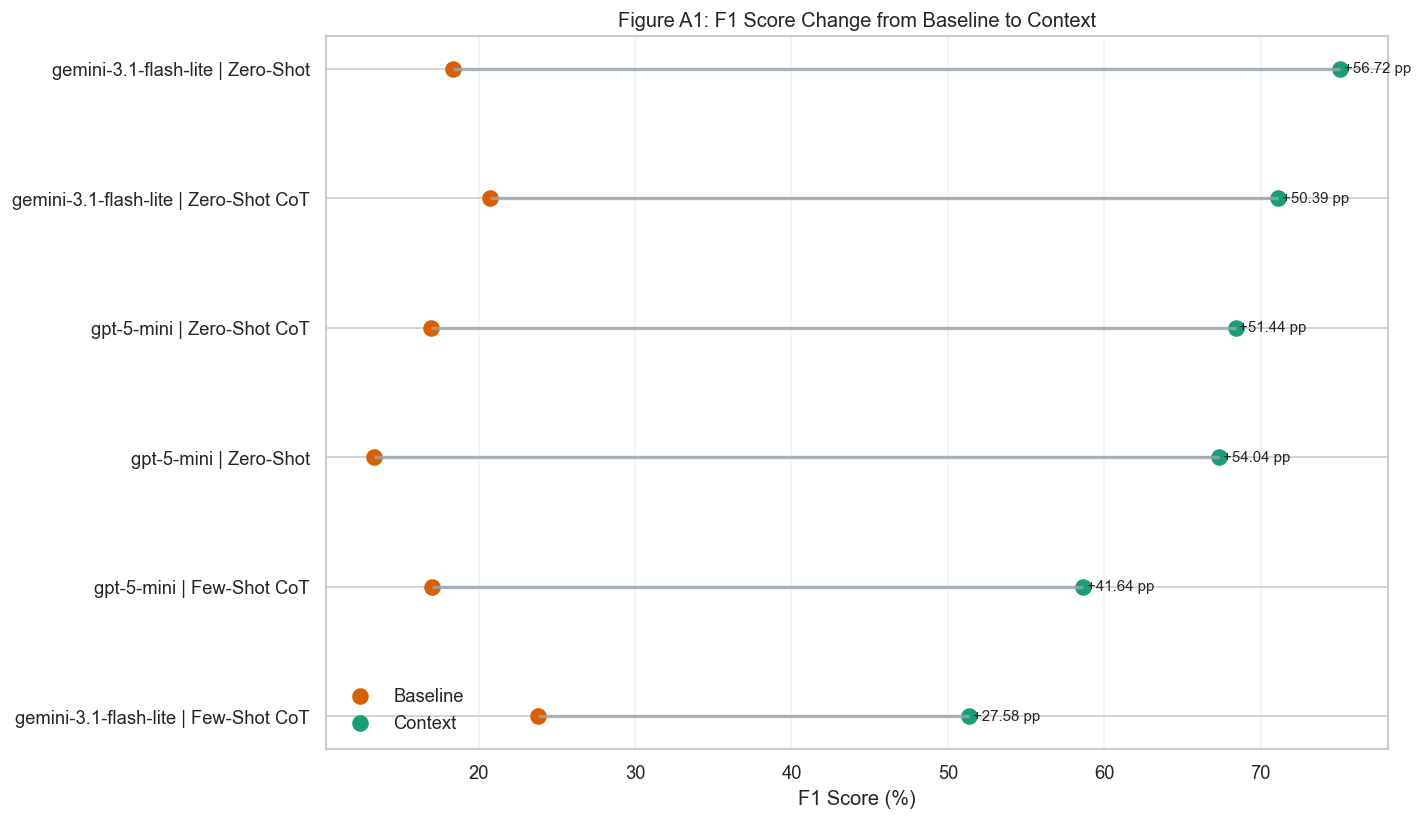

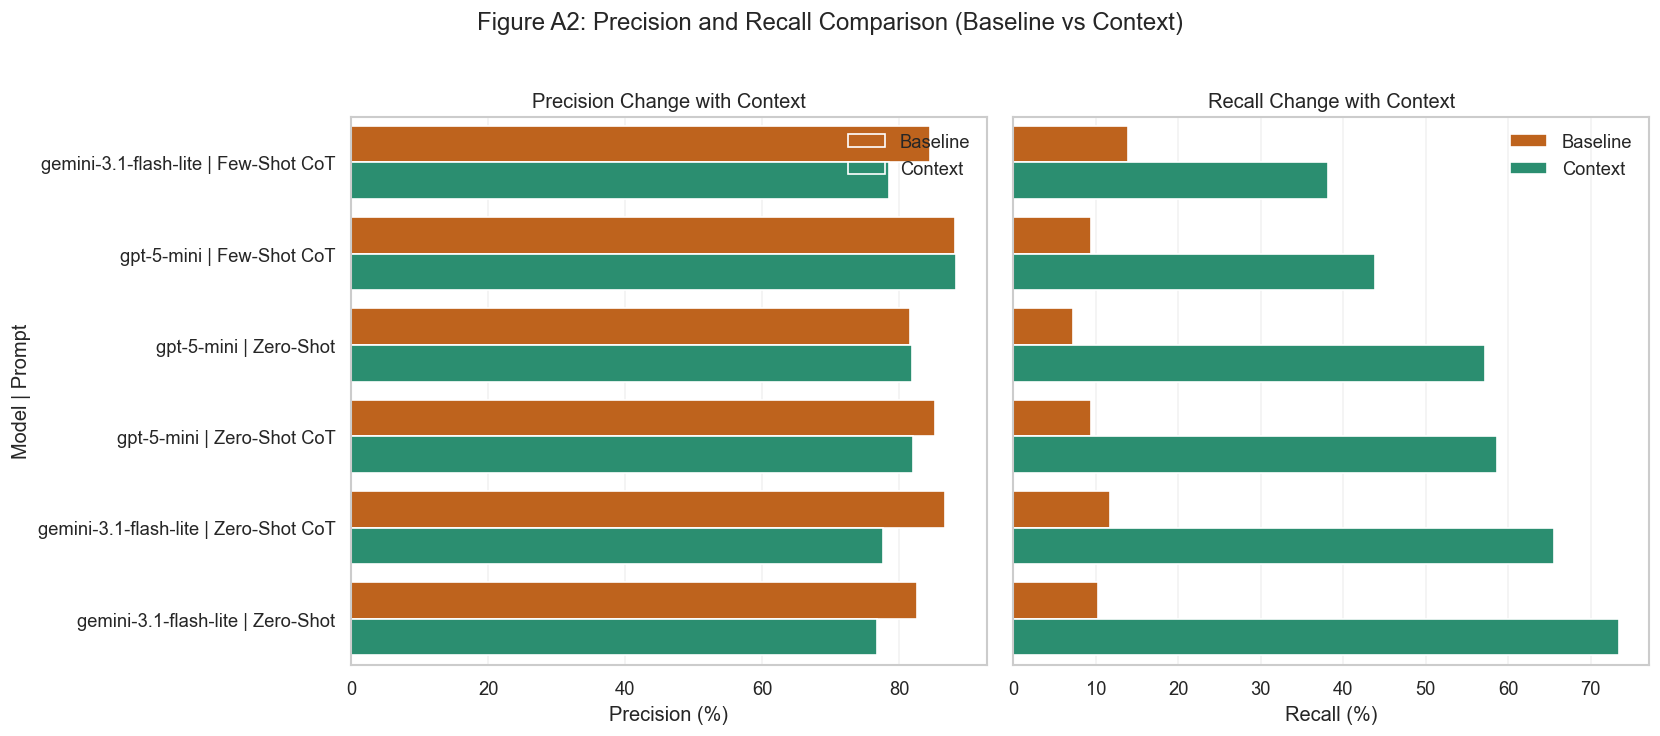

In [166]:
# ============================================================
# Diagram 1-2: Binary metric change with context
# ============================================================

metric_plot_df = comparison_df.copy()

for col in ["Baseline F1", "Context F1", "Baseline Precision", "Context Precision", "Baseline Recall", "Context Recall"]:
    metric_plot_df[col] = pct(metric_plot_df[col]).round(2)

metric_plot_df["Label"] = metric_plot_df["Model"] + " | " + metric_plot_df["Prompt"]
metric_plot_df = metric_plot_df.sort_values("Context F1", ascending=True).reset_index(drop=True)

# Diagram 1: F1 before vs after context (dumbbell chart)
fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(metric_plot_df))

ax.hlines(
    y=y,
    xmin=metric_plot_df["Baseline F1"],
    xmax=metric_plot_df["Context F1"],
    color="#9aa4b2",
    linewidth=2,
    alpha=0.8,
)

ax.scatter(metric_plot_df["Baseline F1"], y, s=80, label="Baseline", color="#d95f02")
ax.scatter(metric_plot_df["Context F1"], y, s=80, label="Context", color="#1b9e77")

for i, row in metric_plot_df.iterrows():
    delta = row["Context F1"] - row["Baseline F1"]
    ax.text(row["Context F1"] + 0.25, i, f"{delta:+.2f} pp", va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(metric_plot_df["Label"])
ax.set_xlabel("F1 Score (%)")
ax.set_title("Figure A1: F1 Score Change from Baseline to Context")
ax.legend(frameon=False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "figA1_f1_baseline_vs_context.png", bbox_inches="tight")
plt.show()


# Diagram 2: Precision and recall shifts with context
pr_plot_df = metric_plot_df.melt(
    id_vars=["Label"],
    value_vars=["Baseline Precision", "Context Precision", "Baseline Recall", "Context Recall"],
    var_name="Metric",
    value_name="Value",
)

pr_plot_df[["Setting", "Measure"]] = pr_plot_df["Metric"].str.split(" ", n=1, expand=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for idx, measure in enumerate(["Precision", "Recall"]):
    sub = pr_plot_df[pr_plot_df["Measure"] == measure]

    sns.barplot(
        data=sub,
        x="Value",
        y="Label",
        hue="Setting",
        orient="h",
        palette={"Baseline": "#d95f02", "Context": "#1b9e77"},
        ax=axes[idx],
    )

    axes[idx].set_title(f"{measure} Change with Context")
    axes[idx].set_xlabel(f"{measure} (%)")
    axes[idx].set_ylabel("" if idx == 1 else "Model | Prompt")
    axes[idx].grid(axis="x", alpha=0.25)
    axes[idx].legend(frameon=False)

plt.suptitle("Figure A2: Precision and Recall Comparison (Baseline vs Context)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figA2_precision_recall_baseline_vs_context.png", bbox_inches="tight")
plt.show()

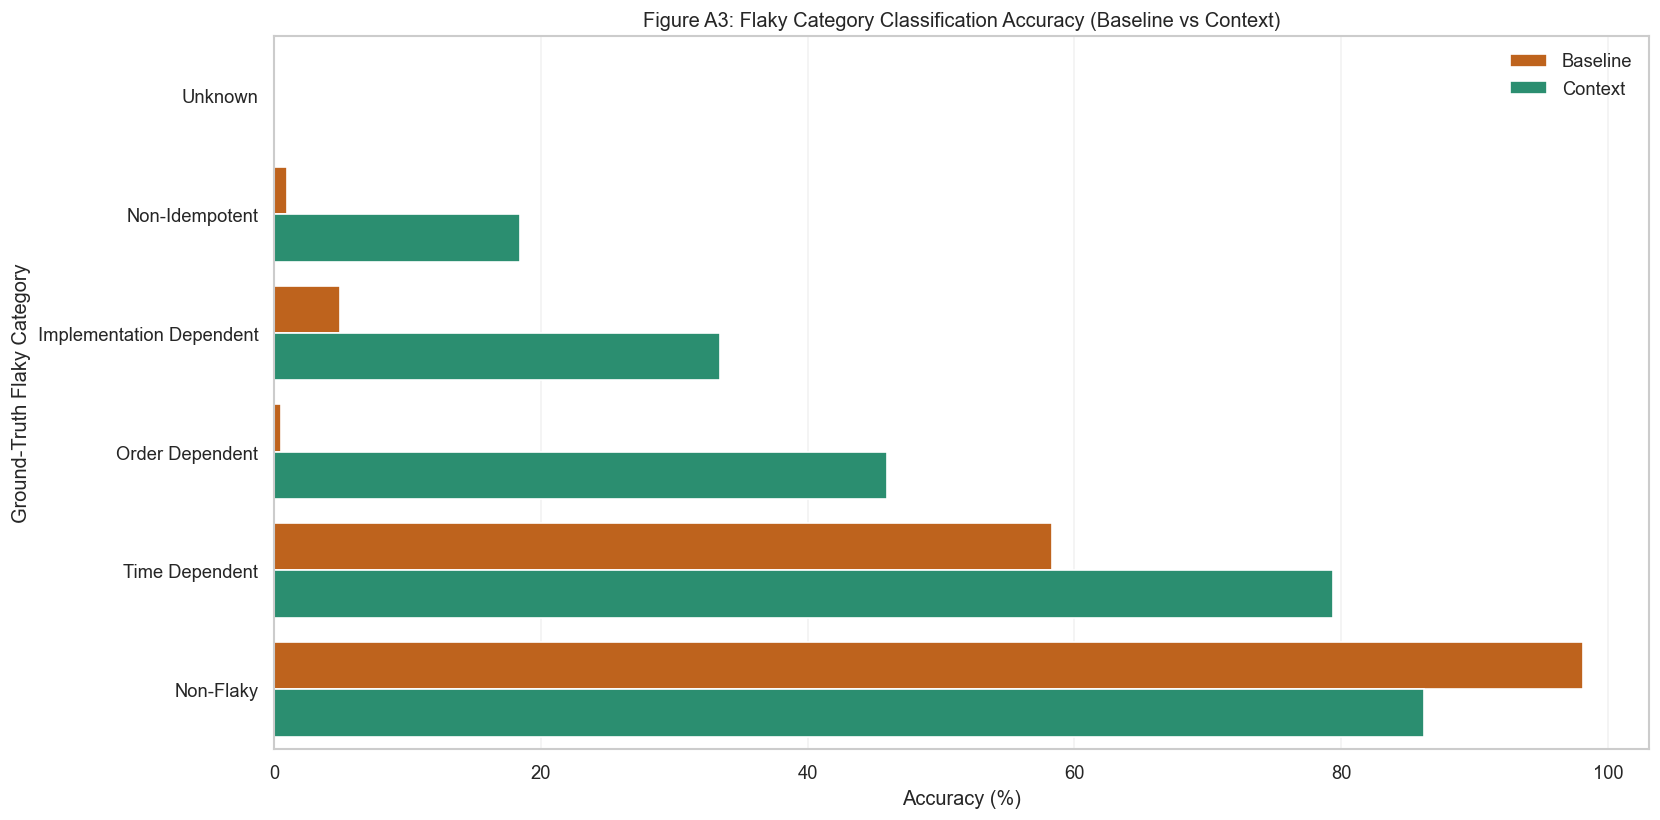

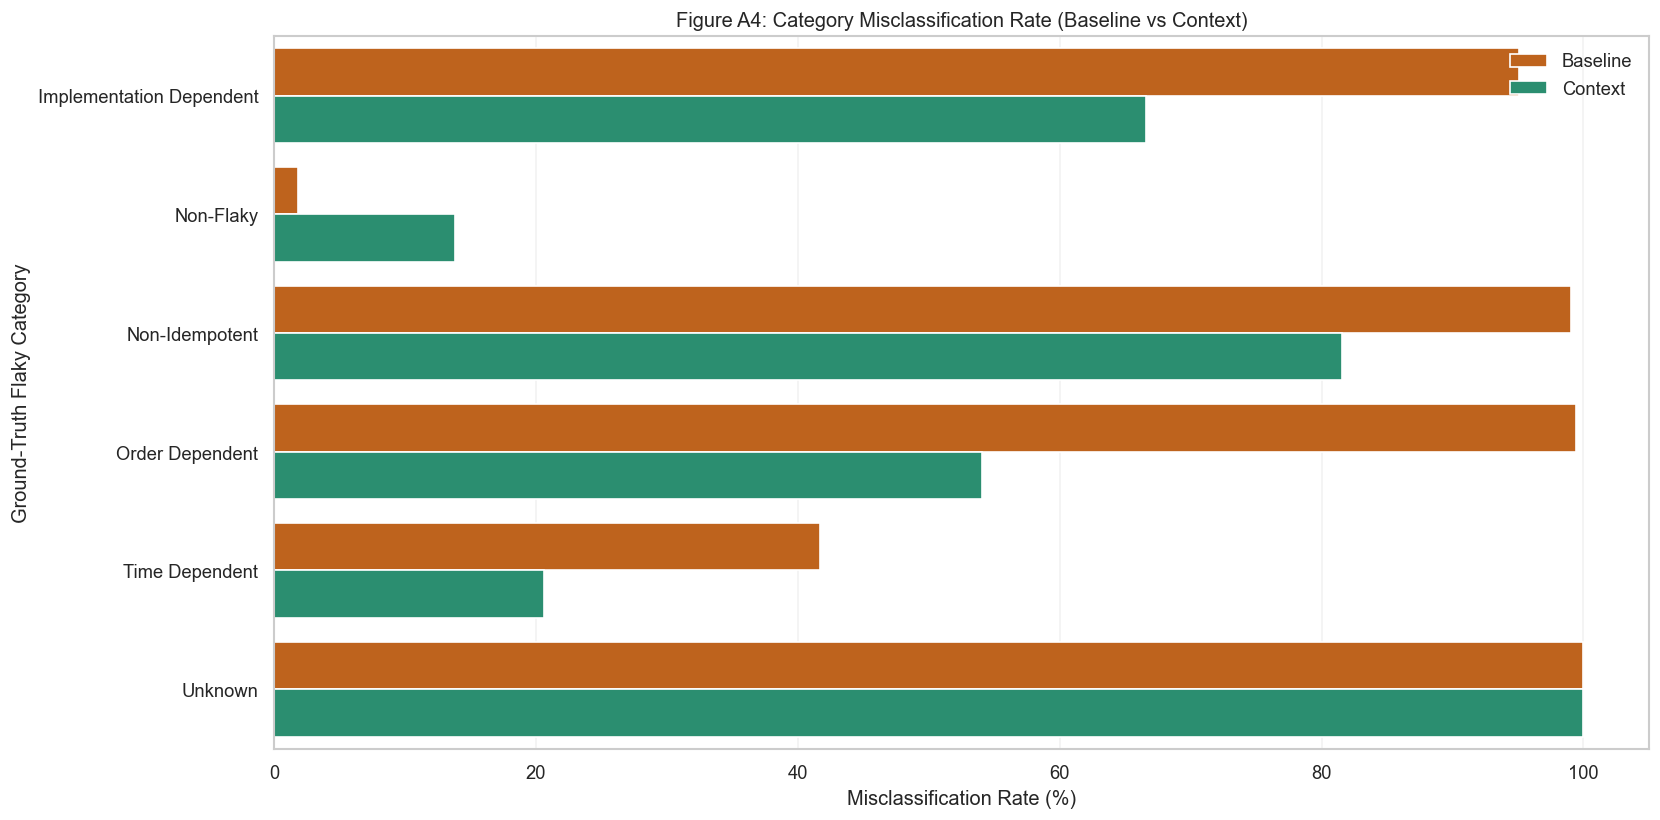

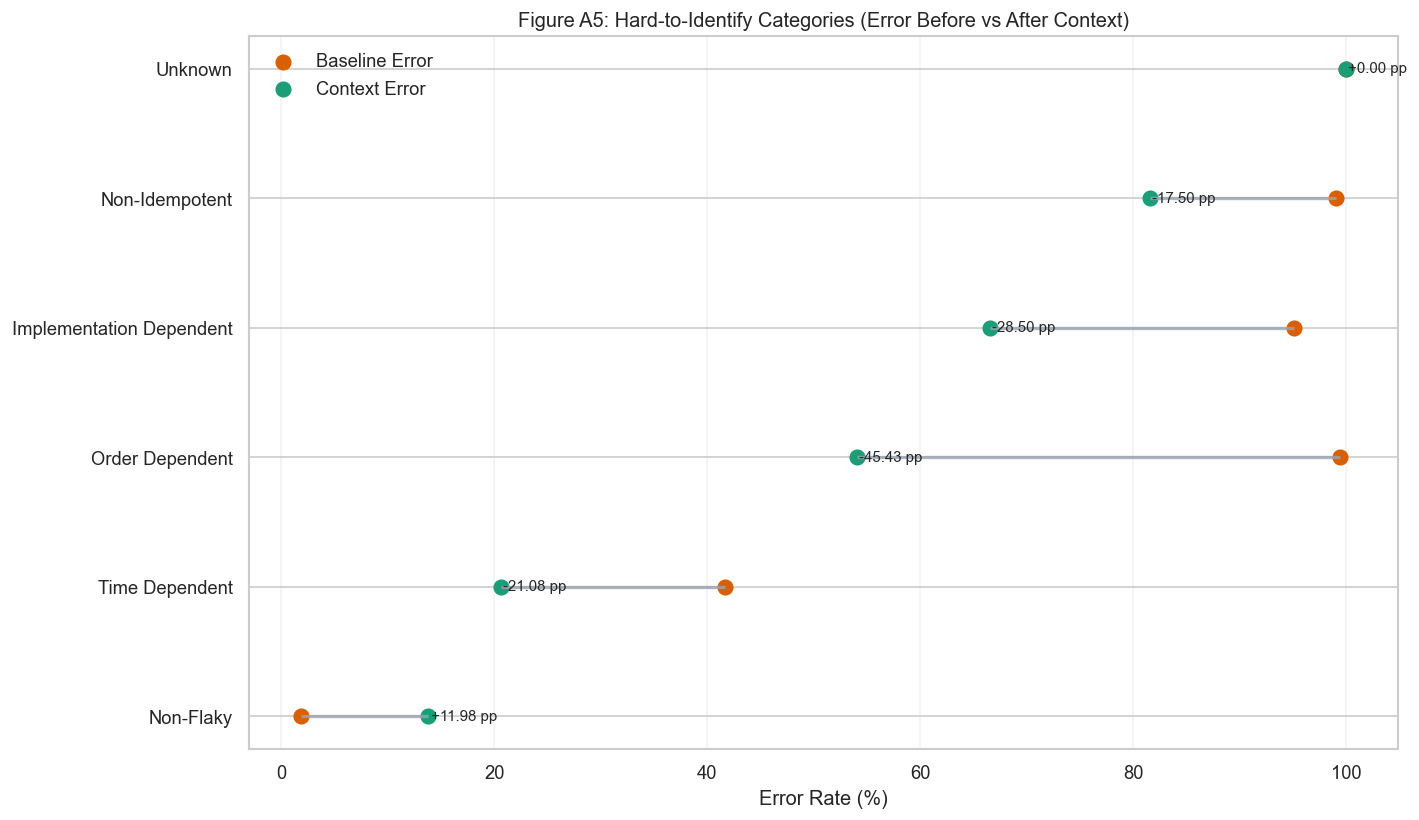

,Actual Category,Predicted As,Count,Percentage (%),Context
0,Implementation Dependent,Non-Flaky,4427,69.38,Baseline
20,Implementation Dependent,Non-Flaky,2240,42.49,Context
8,Non-Idempotent,Non-Flaky,712,11.16,Baseline
11,Order Dependent,Non-Flaky,693,10.86,Baseline
22,Implementation Dependent,Order Dependent,436,8.27,Context
29,Non-Idempotent,Non-Flaky,404,7.66,Context
23,Implementation Dependent,Time Dependent,354,6.71,Context
26,Non-Flaky,Order Dependent,279,5.29,Context
24,Non-Flaky,Implementation Dependent,254,4.82,Context
21,Implementation Dependent,Non-Idempotent,230,4.36,Context


In [167]:
# ============================================================
# Diagram 3-5: Category performance and misclassification behavior
# ============================================================

# Diagram 3: Category classification accuracy with and without context
cat_long = category_compare.melt(
    id_vars=["gt_category", "Samples", "Accuracy Delta (pp)"],
    value_vars=["Baseline Accuracy (%)", "Context Accuracy (%)"],
    var_name="Setting",
    value_name="Accuracy (%)",
)

cat_long["Setting"] = cat_long["Setting"].str.replace(" Accuracy (%)", "", regex=False)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=cat_long,
    x="Accuracy (%)",
    y="gt_category",
    hue="Setting",
    palette={"Baseline": "#d95f02", "Context": "#1b9e77"},
)

plt.title("Figure A3: Flaky Category Classification Accuracy (Baseline vs Context)")
plt.xlabel("Accuracy (%)")
plt.ylabel("Ground-Truth Flaky Category")
plt.grid(axis="x", alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figA3_category_accuracy_baseline_vs_context.png", bbox_inches="tight")
plt.show()


# Diagram 4: Misclassification volume by category and setting
mis_volume = (
    pd.concat([
        baseline.assign(Context="Baseline"),
        context_df.assign(Context="Context"),
    ], ignore_index=True)
    .assign(is_wrong=lambda d: d["gt_category"] != d["pred_category"])
    .groupby(["Context", "gt_category"], as_index=False)
    .agg(
        Misclassified=("is_wrong", "sum"),
        Total=("is_wrong", "count"),
    )
)

mis_volume["Misclassification Rate (%)"] = (
    mis_volume["Misclassified"] / mis_volume["Total"] * 100
).round(2)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=mis_volume,
    x="Misclassification Rate (%)",
    y="gt_category",
    hue="Context",
    palette={"Baseline": "#d95f02", "Context": "#1b9e77"},
)

plt.title("Figure A4: Category Misclassification Rate (Baseline vs Context)")
plt.xlabel("Misclassification Rate (%)")
plt.ylabel("Ground-Truth Flaky Category")
plt.grid(axis="x", alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figA4_category_misclassification_rate_baseline_vs_context.png", bbox_inches="tight")
plt.show()


# Diagram 5: Hardest categories to identify (higher error = harder)
hard_plot = hard_categories.copy().sort_values("Context Error Rate (%)", ascending=True).reset_index(drop=True)

y = np.arange(len(hard_plot))
fig, ax = plt.subplots(figsize=(12, 7))

ax.hlines(
    y=y,
    xmin=hard_plot["Baseline Error Rate (%)"],
    xmax=hard_plot["Context Error Rate (%)"],
    color="#9aa4b2",
    linewidth=2,
    alpha=0.8,
)
ax.scatter(hard_plot["Baseline Error Rate (%)"], y, s=75, color="#d95f02", label="Baseline Error")
ax.scatter(hard_plot["Context Error Rate (%)"], y, s=75, color="#1b9e77", label="Context Error")

for i, row in hard_plot.iterrows():
    delta = row["Context Error Rate (%)"] - row["Baseline Error Rate (%)"]
    ax.text(row["Context Error Rate (%)"] + 0.2, i, f"{delta:+.2f} pp", va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(hard_plot["gt_category"])
ax.set_xlabel("Error Rate (%)")
ax.set_title("Figure A5: Hard-to-Identify Categories (Error Before vs After Context)")
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "figA5_hard_categories_error_shift.png", bbox_inches="tight")
plt.show()


# Optional table for reporting specific confusion transitions
top_mis_transitions = mis_compare.sort_values("Count", ascending=False).head(20)
display(top_mis_transitions)

## 8.2 Dataset Balance & Statistical Robustness Check

The category-level tables above (§7, §8.1) are computed on `context_df` / `baseline`, which stack **all 6 model×prompt configurations** on top of the same 2,210 unique test cases (13,260 stacked rows each). This means a category's "sample size" in those tables is inflated 6× relative to the number of *independent* test cases actually available, and the 6 repeated evaluations of the same test case are correlated rather than independent draws. This section re-derives category counts from the true underlying benchmark file to (a) confirm the binary class balance, (b) quantify category imbalance, and (c) attach realistic confidence intervals to small categories.


In [168]:
# ============================================================
# Dataset Balance & Statistical Robustness Check
# ============================================================

eval_path = Path("../datasets/evaluation_dataset.jsonl")

records = []
with open(eval_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

base_dataset_df = pd.DataFrame(records)

n_unique = len(base_dataset_df)
n_configs = df["experiment"].nunique()

class_dist = base_dataset_df["isFlaky"].value_counts()
category_counts = base_dataset_df["issue_category"].value_counts()

print(f"Unique test cases in evaluation_dataset.jsonl : {n_unique:,}")
print(f"Experimental configurations (model x prompt x context) : {n_configs}")
print(f"Stacked rows per context setting (n_unique x 6 configs) : {n_unique * 6:,}\n")

print("Binary class distribution (unique test cases):")
display(class_dist)

print("\nCategory distribution (unique test cases):")
display(category_counts)

# 95% CI half-width using the true unique sample size for each category,
# rather than the 6x-inflated stacked count used in section 7/8.1 tables.
true_n = category_counts.to_dict()

ci_rows = []
for cat, n in true_n.items():
    p = category_compare.set_index("gt_category").loc[cat, "Context Accuracy (%)"] / 100 if cat in category_compare["gt_category"].values else np.nan
    se = np.sqrt(p * (1 - p) / n) if pd.notna(p) else np.nan
    ci_rows.append({
        "Category": cat,
        "True Unique n": n,
        "Context Accuracy (%)": round(p * 100, 2) if pd.notna(p) else np.nan,
        "95% CI Half-Width (pp)": round(1.96 * se * 100, 2) if pd.notna(se) else np.nan,
    })

ci_df = pd.DataFrame(ci_rows).sort_values("True Unique n")
print("\nTrue-n confidence intervals (vs. inflated stacked-n tables above):")
display(ci_df)


Unique test cases in evaluation_dataset.jsonl : 2,210
Experimental configurations (model x prompt x context) : 12
Stacked rows per context setting (n_unique x 6 configs) : 13,260

Binary class distribution (unique test cases):


isFlaky
True     1105
False    1105
Name: count, dtype: int64


Category distribution (unique test cases):


issue_category
Non-Flaky                   1105
Implementation Dependent     816
Order Dependent              124
Non-Idempotent               121
Time Dependent                34
Unknown                       10
Name: count, dtype: int64


True-n confidence intervals (vs. inflated stacked-n tables above):


,Category,True Unique n,Context Accuracy (%),95% CI Half-Width (pp)
5,Unknown,10,0.00,0.00
4,Time Dependent,34,79.41,13.59
3,Non-Idempotent,121,18.46,6.91
2,Order Dependent,124,45.97,8.77
1,Implementation Dependent,816,33.42,3.24
0,Non-Flaky,1105,86.18,2.03


### Interpretation

The binary Flaky/Non-Flaky split is exactly balanced (1,105 / 1,105), so overall accuracy, precision, recall, and F1 figures in §3–§4 are not distorted by class imbalance. However, the flaky **category** distribution is highly imbalanced: Implementation Dependent accounts for ~74% of all flaky tests, while Time Dependent (34 unique cases) and Unknown (10 unique cases) are rare. Consequently, category-level accuracy figures for Time Dependent and Order Dependent in particular carry wide confidence intervals (see table above) and should be read as indicative rather than precise — a handful of additional labelled examples could shift these percentages by several points. This does not change the qualitative pattern (Implementation Dependent and Non-Idempotent are the hardest categories), but it does mean the exact accuracy percentages for low-n categories should not be over-interpreted. This caveat is expanded in §9 (Limitations and Threats to Validity).


# 9. Limitations and Threats to Validity

**Construct validity — category accuracy metric.** An earlier version of §7's category-level analysis conflated *binary* correctness (Flaky vs. Non-Flaky) with *category-exact-match* accuracy. This has been corrected throughout §7 and §8; all category accuracy figures reported in this notebook now require the predicted subtype to exactly match the ground-truth subtype.

**Internal validity — pseudo-replication across stacked configurations.** The combined dataframe (`df`) stacks 6 model×prompt configurations on top of the same 2,210 unique test cases. Any table computed directly on `df`, `baseline`, or `context_df` therefore has an apparent sample size that is 6× the number of independent test cases, and the 6 repeated evaluations of a given test case are correlated (same test, same ground truth, only the model/prompt differs). §8.2 recomputes category counts against the true unique-record benchmark and shows that rare categories (Time Dependent, n=34; Unknown, n=10) carry substantially wider uncertainty than the stacked-count tables would suggest.

**External validity — single benchmark, two models.** All findings are derived from one 2,210-record benchmark evaluated with two LLMs (Gemini 3.1 Flash Lite, GPT-5 Mini) and three prompting strategies. Results have not been validated against an external/held-out project or additional model families, so claims about "LLM-based flaky test identification" in general should be read as "for the two evaluated frontier LLMs on this benchmark."

**Category imbalance.** Among flaky tests, Implementation Dependent (73.8%) dominates the category distribution, while Time Dependent (3.1%) and Unknown (0.9%) are rare. Category-level accuracy comparisons should weight this imbalance into their interpretation — a macro-average across categories treats a 34-sample category the same as an 816-sample category, while a sample-weighted average is dominated by the majority category. Both are reported where relevant rather than a single unqualified "category accuracy."

**Ground-truth reliability.** Flaky test category labels originate from the upstream dataset construction pipeline (see [`data-extraction-pipeline`](../data-extraction-pipeline/README.md)) and were not independently re-verified as part of this evaluation notebook; any labelling noise in the source dataset propagates into every metric reported here.

**Reproducibility.** Bootstrap confidence intervals (§3) and the qualitative failed-example sample (§7.4) use fixed seeds (`random_state=42`) so re-running this notebook reproduces identical figures. The full experimental predictions are read from `results/<model>/<prompt>/<context>/predictions.jsonl`; re-generating those predictions (rather than re-analyzing them) depends on the upstream batch API pipeline (see [`09_batch_api.md`](../docs/09_batch_api.md)) and is outside the scope of this notebook.


# 10. Overall Conclusion

| Hypothesis | Statement | Verdict |
|---|---|---|
| H1 (RQ1) | Modern LLMs can identify flaky tests with reasonable accuracy using only test code. | Partially supported — high precision (82–88%), low recall (7–14%). |
| H2 (RQ2) | Contextual software artefacts significantly improve classification performance. | Supported — up to +56.7 F1 points, significant under every McNemar test after Holm-Bonferroni correction. |
| H3 (RQ3) | Structured reasoning prompts outperform direct Zero-Shot prompting. | Partially supported — true only without context; Few-Shot CoT becomes the weakest strategy once context is available. |
| H4 (RQ4) | Production code and runtime failure information contribute more than helper methods alone. | Supported — Failure Log (97%) and Production Code (75%) utilization far exceed Helper Methods (39%) in successful classifications. |
| H5 (RQ5) | Flaky tests with ambiguous or implicit causes remain harder to identify than those with explicit runtime evidence. | Supported — true subtype-match accuracy for Non-Idempotent (18.46%) and Implementation Dependent (33.42%) trails Non-Flaky (86.18%) and Time Dependent (79.41%) by a wide margin. |

Taken together, the results show that contextual software artefacts are the single largest lever for improving LLM-based flaky test identification, prompting strategy is only useful when context is scarce, and the framework's remaining weakness is correctly identifying *why* a test is flaky when the evidence is implicit rather than visible in a single failing run (Non-Idempotent and Implementation Dependent categories). This weakness is measured conservatively: because Time Dependent and Order Dependent categories have small unique sample sizes (§8.2), the exact magnitude of the gap should be treated as indicative pending validation on a larger or external benchmark (§9).
